In [2]:
import os
import ast
import shutil
import datetime
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Rename all our files to something consistent

In [3]:
data_files = os.listdir('PumpControl/data')

for f in data_files:
    if 'pump-control' in f:
        continue
    nf = f.replace('data', 'pump-control')
    f = os.path.join('PumpControl/data', f)
    nf = os.path.join('PumpControl/data', nf)
    shutil.move(f, nf)

Now we filter out the data file which don't include time stamps.

In [30]:
base = 'PumpControl/data'
data_files = os.listdir(base)

time_data_files = []
for f in data_files:
    f = os.path.join('PumpControl/data', f)
    time_data_files += [f]
time_data_files = sorted(time_data_files)

In [61]:
fn1 = time_data_files[0]
date = '2025' + fn1.split('2025')[-1].split('.')[0] + ' 00:00:00'
mdf = pd.read_csv(fn1)
mdf['Time'] = date
for f in time_data_files[1:]:

    df = pd.read_csv(f)
    if 'Time' not in df.columns:
        date = '2025' + f.split('2025')[-1].split('.')[0] + ' 00:00:00'
        df['Time'] = date
    mdf = pd.concat([mdf, df])

mdf.to_csv('PumpControl/data/pump-control-master.csv', index=False)

In [110]:
df = pd.read_csv('PumpControl/data/pump-control-master.csv', low_memory=False)
mask = df['readings_pH'].notnull()
dfm = df.copy()
dfm

,pH,analog_pH,NH3,analog_NH3,readings_pH,readings_NH3,pump on,mode,pH_curve,NH3_curve,Unnamed: 10,Unnamed: 11,Time
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.01671, -0.135]","[0.20304, -82.29873]",NaN,NaN,2025-01-14 00:00:00
1,3.592374,223.0625,-16.513770,324.0000,"[224, 224, 223, 223, 223, 223, 223, 223, 223, ...","[324, 324, 324, 324, 324, 324, 324, 324, 325, ...",True,on,NaN,NaN,NaN,NaN,2025-01-14 00:00:00
2,3.596552,223.3125,-16.513770,324.0000,"[224, 223, 223, 224, 223, 223, 224, 223, 224, ...","[324, 324, 324, 324, 324, 324, 324, 324, 324, ...",True,on,NaN,NaN,NaN,NaN,2025-01-14 00:00:00
3,3.591330,223.0000,-16.513770,324.0000,"[223, 223, 223, 223, 223, 223, 223, 223, 223, ...","[324, 324, 324, 324, 324, 324, 324, 324, 324, ...",True,on,NaN,NaN,NaN,NaN,2025-01-14 00:00:00
4,3.595508,223.2500,-16.513770,324.0000,"[223, 223, 224, 224, 223, 224, 223, 223, 223, ...","[324, 324, 324, 324, 324, 324, 324, 324, 324, ...",True,on,NaN,NaN,NaN,NaN,2025-01-14 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
300167,10.967450,631.0000,80.518844,400.3750,"[631, 631, 631, 631, 631, 631, 631, 631, 631, ...","[401, 400, 401, 400, 400, 400, 400, 401, 401, ...",False,auto,NaN,NaN,NaN,NaN,2025-07-04 02:42:17
300168,10.967450,631.0000,76.684339,400.2500,"[631, 631, 631, 631, 631, 631, 631, 631, 631, ...","[401, 400, 400, 400, 400, 401, 400, 401, 400, ...",False,auto,NaN,NaN,NaN,NaN,2025-07-04 02:42:20
300169,10.967450,631.0000,76.684339,400.2500,"[631, 631, 631, 631, 631, 631, 631, 631, 631, ...","[400, 401, 400, 400, 400, 400, 401, 401, 400, ...",False,auto,NaN,NaN,NaN,NaN,2025-07-04 02:42:24
300170,10.967450,631.0000,82.507411,400.4375,"[631, 631, 631, 631, 631, 631, 631, 631, 631, ...","[400, 400, 400, 400, 400, 400, 401, 400, 401, ...",False,auto,NaN,NaN,NaN,NaN,2025-07-04 02:42:27


In [112]:
for i, r in dfm.iterrows():
    if np.isnan(r['pH']):
        continue

    ph = np.sort(ast.literal_eval(r['readings_pH']))# [2:-2]
    ph_m = np.mean(ph)
    ph_s = np.std(ph)
    nh3 = np.sort(ast.literal_eval(r['readings_NH3']))# [2:-2]
    nh3_m = np.mean(nh3)
    nh3_s = np.std(nh3)

    ostd = 2

    ph_o = (ph > ph_m + ostd * ph_s) | (ph < ph_m - ostd * ph_s)
    ph_me = np.median(ph[~ph_o])

    nh3_o = (nh3 > nh3_m + ostd * nh3_s) | (nh3 < nh3_m - ostd * nh3_s)
    nh3_me = np.median(nh3[~nh3_o])

    dfm.loc[i, 'smoothed_pH'] = ph_me
    dfm.loc[i, 'smoothed_NH3'] = nh3_me
dfm

,pH,analog_pH,NH3,analog_NH3,readings_pH,readings_NH3,pump on,mode,pH_curve,NH3_curve,Unnamed: 10,Unnamed: 11,Time,smoothed_pH,smoothed_NH3
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.01671, -0.135]","[0.20304, -82.29873]",NaN,NaN,2025-01-14 00:00:00,NaN,NaN
1,3.592374,223.0625,-16.513770,324.0000,"[224, 224, 223, 223, 223, 223, 223, 223, 223, ...","[324, 324, 324, 324, 324, 324, 324, 324, 325, ...",True,on,NaN,NaN,NaN,NaN,2025-01-14 00:00:00,223.0,324.0
2,3.596552,223.3125,-16.513770,324.0000,"[224, 223, 223, 224, 223, 223, 224, 223, 224, ...","[324, 324, 324, 324, 324, 324, 324, 324, 324, ...",True,on,NaN,NaN,NaN,NaN,2025-01-14 00:00:00,223.0,324.0
3,3.591330,223.0000,-16.513770,324.0000,"[223, 223, 223, 223, 223, 223, 223, 223, 223, ...","[324, 324, 324, 324, 324, 324, 324, 324, 324, ...",True,on,NaN,NaN,NaN,NaN,2025-01-14 00:00:00,223.0,324.0
4,3.595508,223.2500,-16.513770,324.0000,"[223, 223, 224, 224, 223, 224, 223, 223, 223, ...","[324, 324, 324, 324, 324, 324, 324, 324, 324, ...",True,on,NaN,NaN,NaN,NaN,2025-01-14 00:00:00,223.0,324.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300167,10.967450,631.0000,80.518844,400.3750,"[631, 631, 631, 631, 631, 631, 631, 631, 631, ...","[401, 400, 401, 400, 400, 400, 400, 401, 401, ...",False,auto,NaN,NaN,NaN,NaN,2025-07-04 02:42:17,631.0,400.0
300168,10.967450,631.0000,76.684339,400.2500,"[631, 631, 631, 631, 631, 631, 631, 631, 631, ...","[401, 400, 400, 400, 400, 401, 400, 401, 400, ...",False,auto,NaN,NaN,NaN,NaN,2025-07-04 02:42:20,631.0,400.0
300169,10.967450,631.0000,76.684339,400.2500,"[631, 631, 631, 631, 631, 631, 631, 631, 631, ...","[400, 401, 400, 400, 400, 400, 401, 401, 400, ...",False,auto,NaN,NaN,NaN,NaN,2025-07-04 02:42:24,631.0,400.0
300170,10.967450,631.0000,82.507411,400.4375,"[631, 631, 631, 631, 631, 631, 631, 631, 631, ...","[400, 400, 400, 400, 400, 400, 401, 400, 401, ...",False,auto,NaN,NaN,NaN,NaN,2025-07-04 02:42:27,631.0,400.0


In [113]:
dfm.to_csv('PumpControl/data/pump-control-master-smoothed.csv', index=False)

In [119]:
dph = dfm['analog_pH'] - dfm['smoothed_pH']
dnh3 = dfm['analog_NH3'] - dfm['smoothed_NH3']
print(dph)
print(dnh3)

0            NaN
1         0.0625
2         0.3125
3         0.0000
4         0.2500
           ...  
300167    0.0000
300168    0.0000
300169    0.0000
300170    0.0000
300171    0.0000
Length: 300172, dtype: float64
0            NaN
1         0.0000
2         0.0000
3         0.0000
4         0.0000
           ...  
300167    0.3750
300168    0.2500
300169    0.2500
300170    0.4375
300171    0.4375
Length: 300172, dtype: float64


In [4]:
df = pd.read_csv('PumpControl/data/pump-control-master-smoothed.csv', low_memory=False)

dtype('O')

In [28]:
df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S')
mask0 = df['pH_curve'].notnull() & df['Time'].isnull()
mask1 = df['Time'].dt.time != datetime.time(0, 0, 0)
mask = mask0 | mask1
dft = df[mask].copy()
dft.to_csv('PumpControl/data/pump-control-master-smoothed-timeonly.csv', index=False)

In [4]:
df = pd.read_csv('PumpControl/data/pump-control-master-smoothed-timeonly.csv', low_memory=False)
df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S')

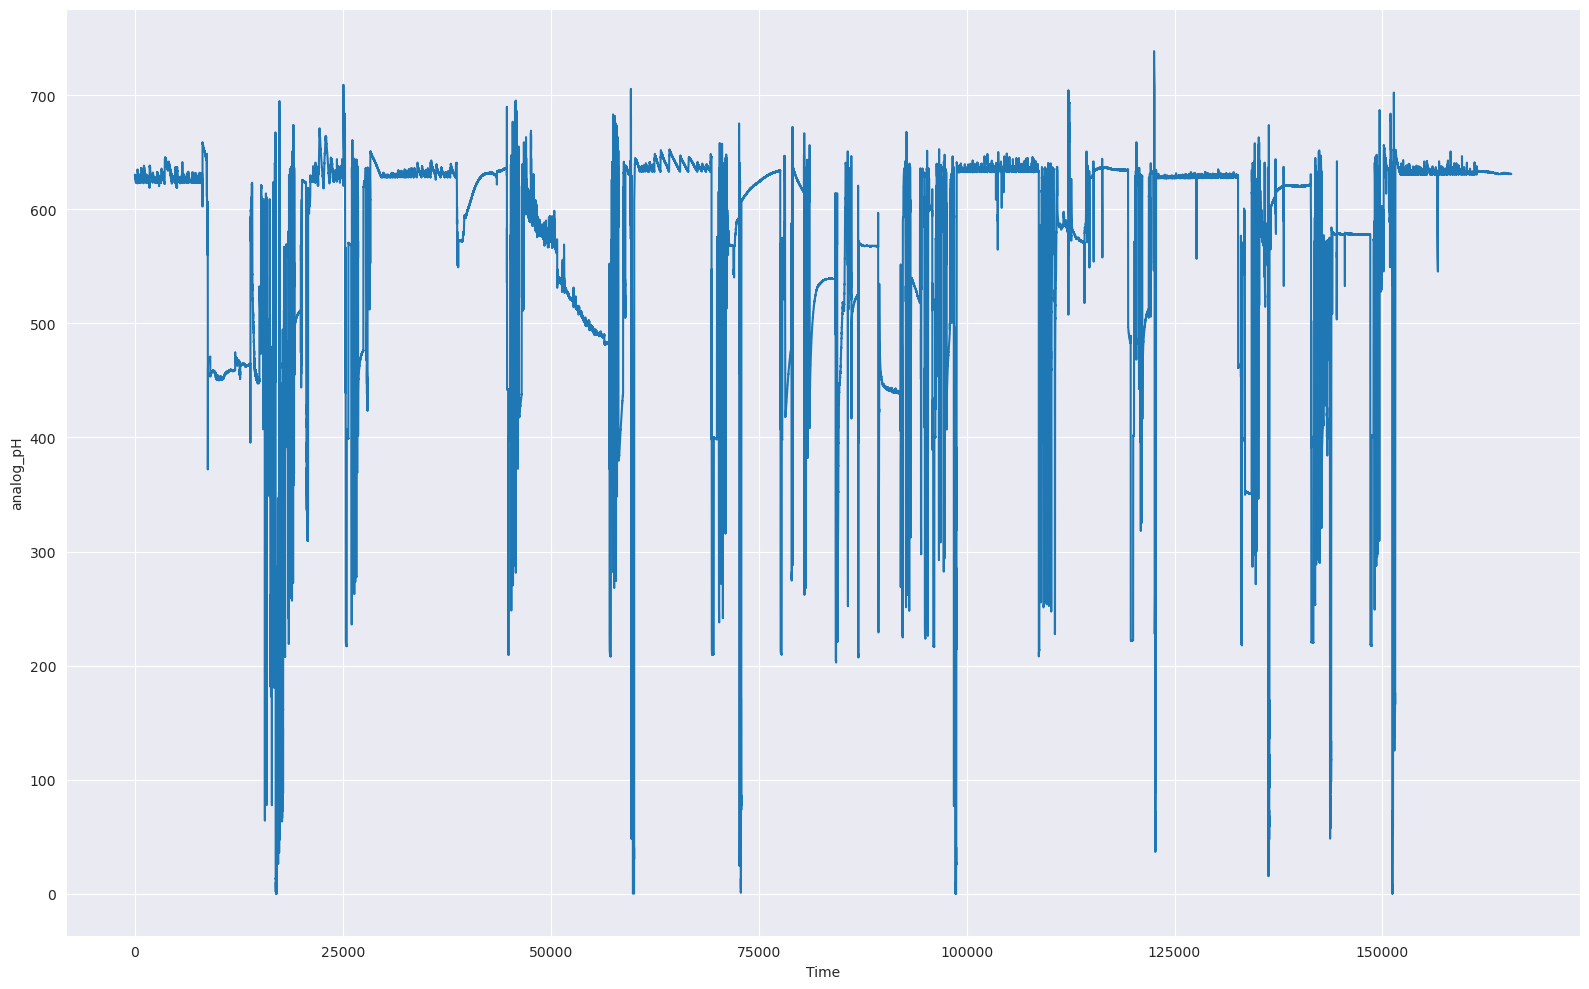

In [18]:
mask = df['Time'].notnull()
dfv = df[mask].copy()

fig, ax = plt.subplots(figsize=(16, 10))
y_label = 'analog_pH'
# y_label = 'smoothed_pH'
y = dfv[y_label]
x = np.arange(len(y))
ax.plot(x, y)
ax.set_xlabel('Time')
ax.set_ylabel(y_label)
plt.tight_layout()
plt.savefig(f'PumpControl/img/{y_label}-spot-check.png')
plt.show()

1           0.0
2           4.0
3           7.0
4          11.0
5          14.0
         ...   
3548    12393.0
3549    12396.0
3550    12400.0
3551    12403.0
3552    12407.0
Name: Time, Length: 3552, dtype: float64


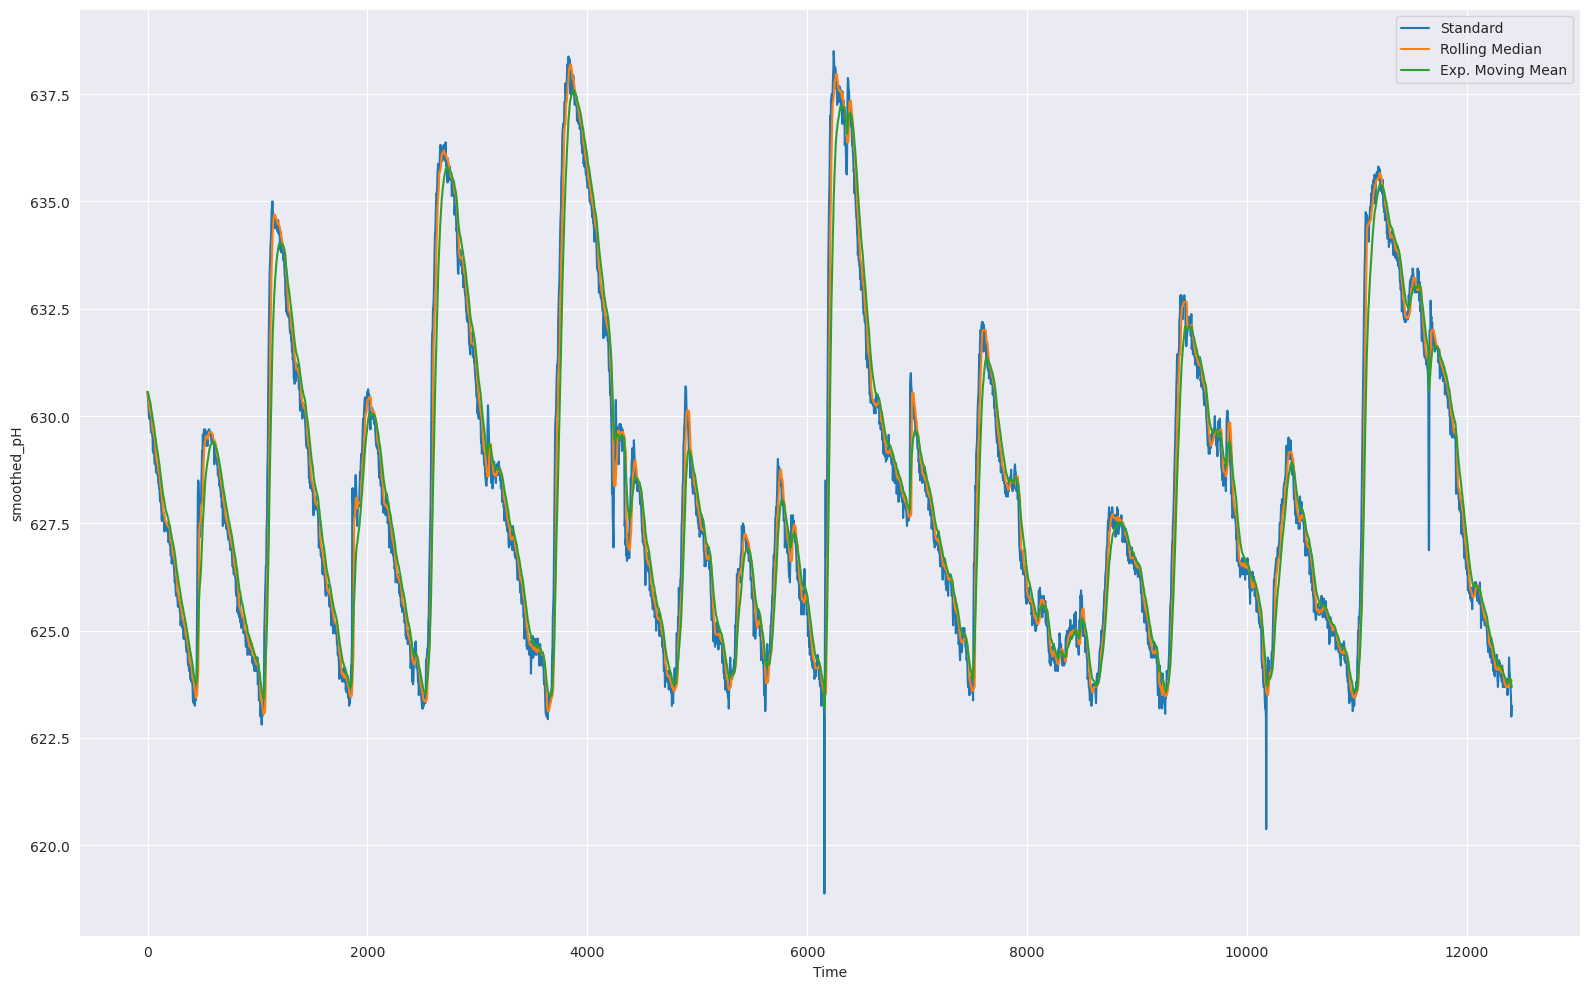

3555        0.0
3556        4.0
3557        7.0
3558       11.0
3559       14.0
         ...   
8652    17804.0
8653    17808.0
8654    17811.0
8655    17815.0
8656    17818.0
Name: Time, Length: 5102, dtype: float64


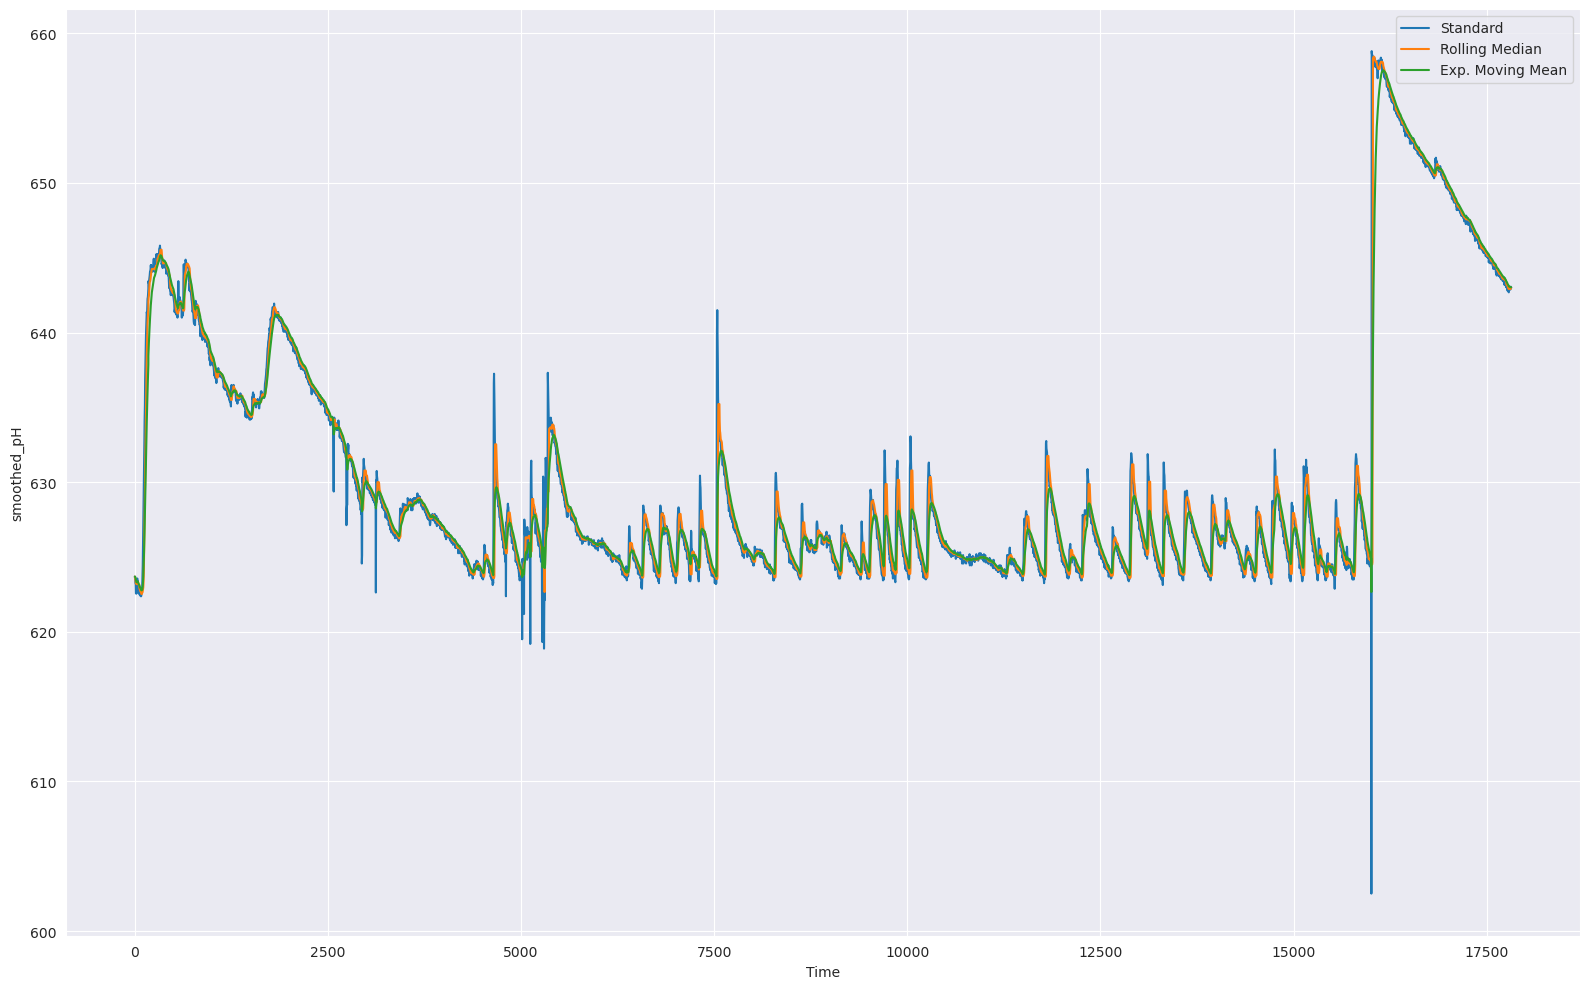

8659    0.0
Name: Time, dtype: float64


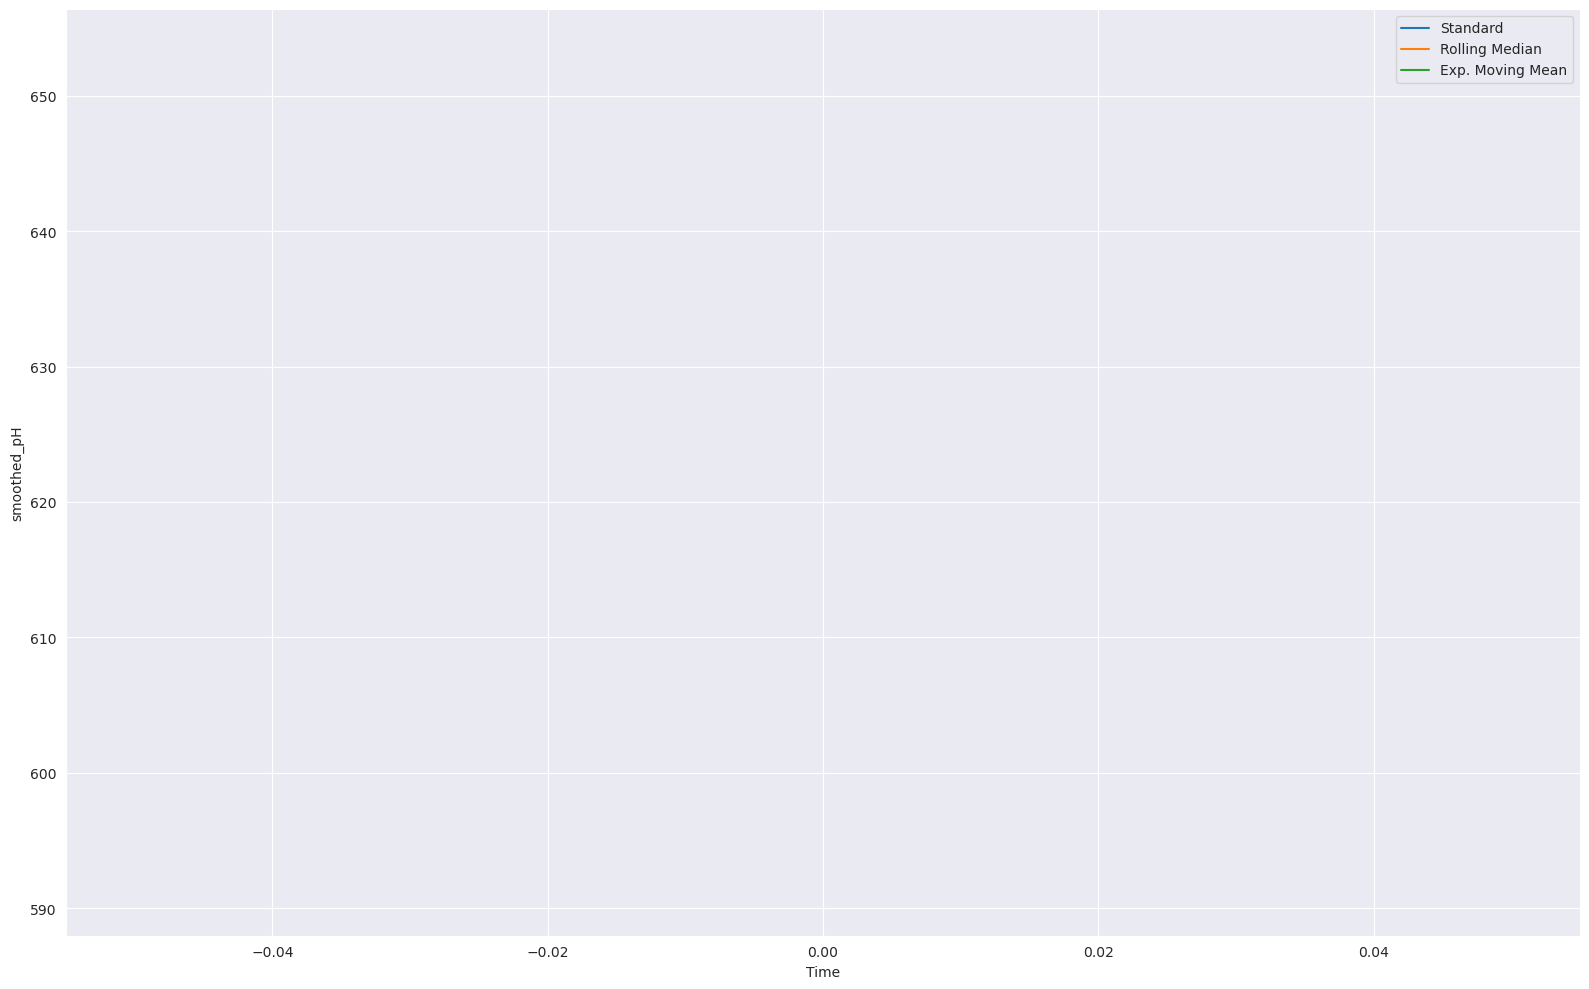

8662    0.0
Name: Time, dtype: float64


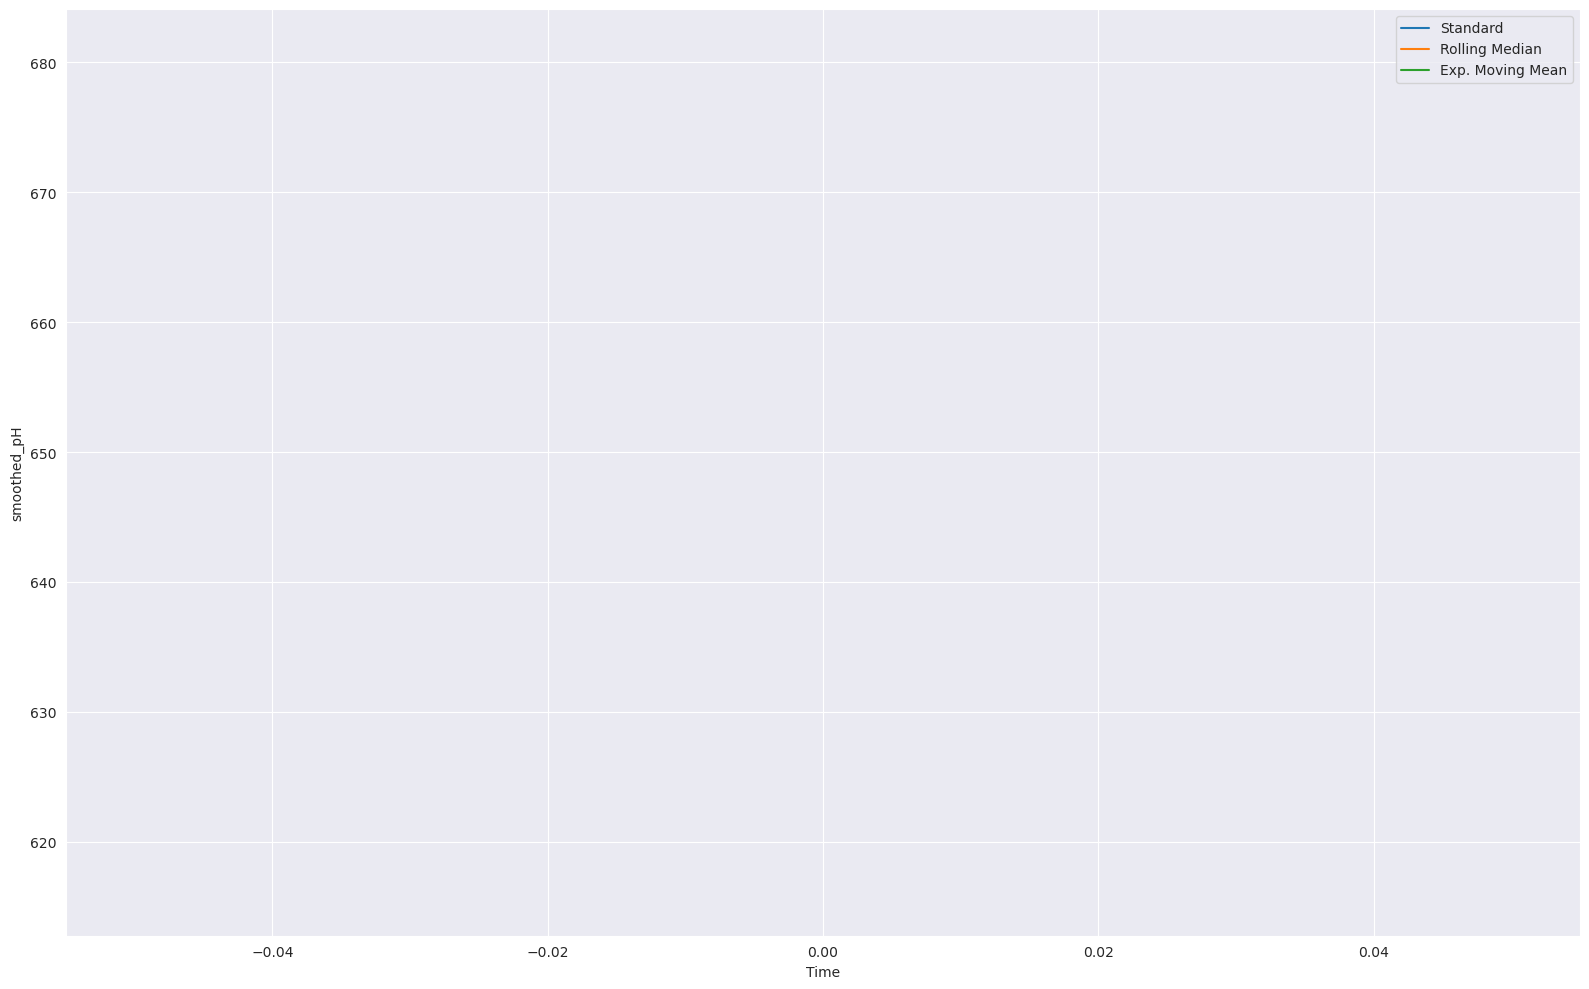

8665    0.0
Name: Time, dtype: float64


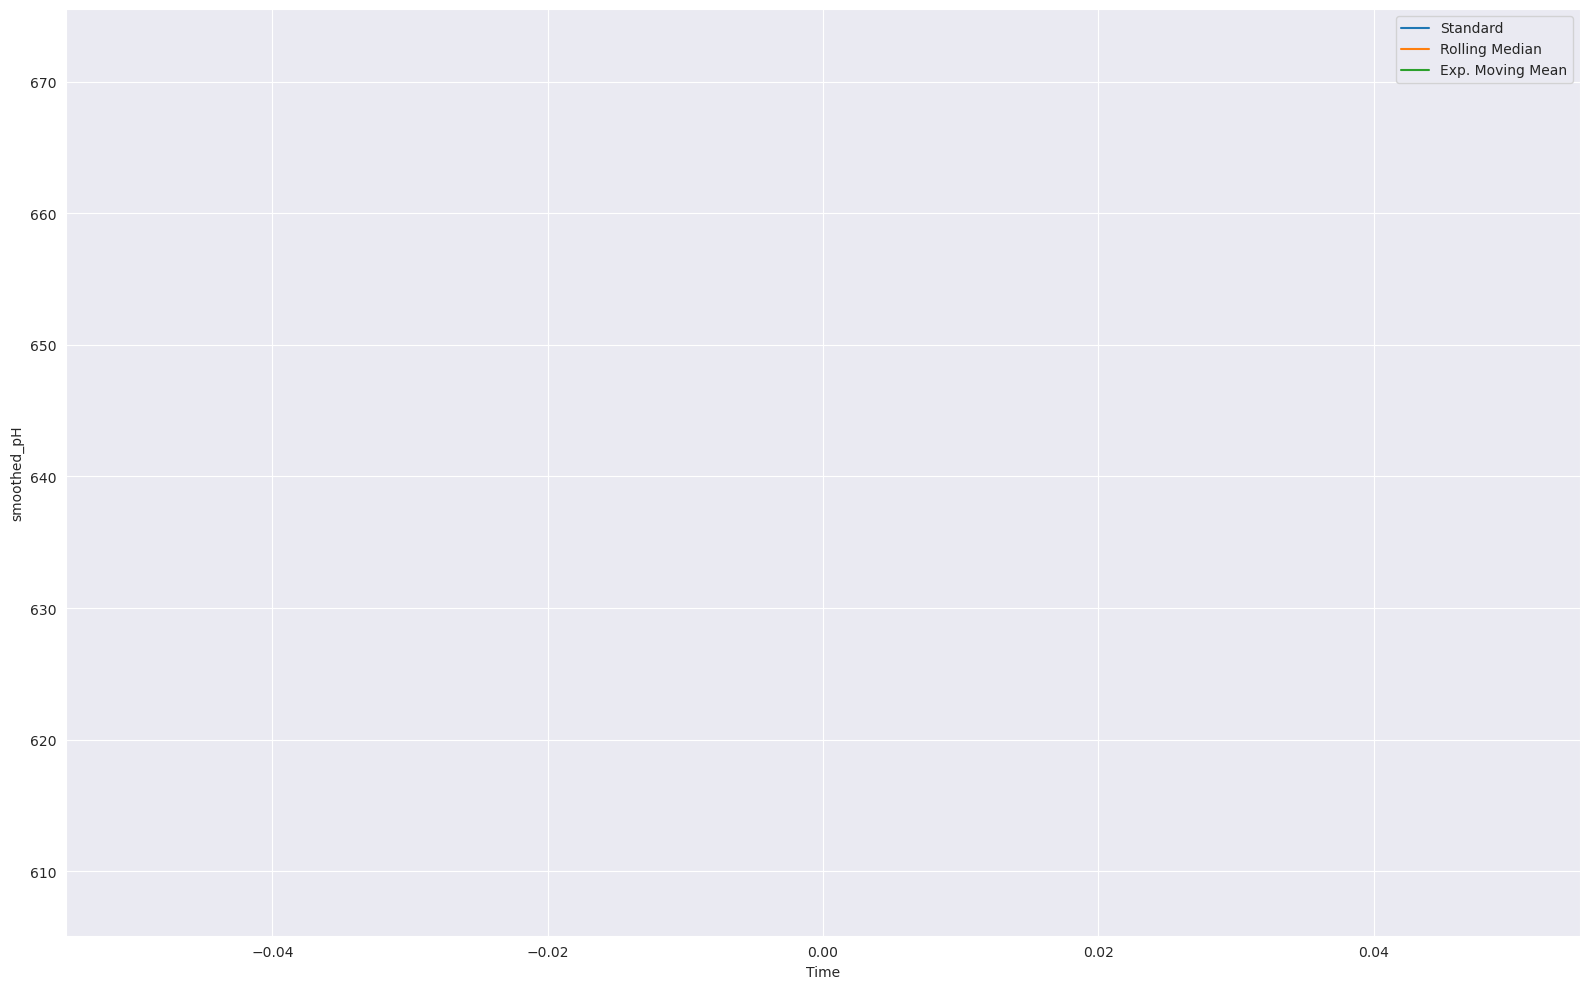

8668    0.0
Name: Time, dtype: float64


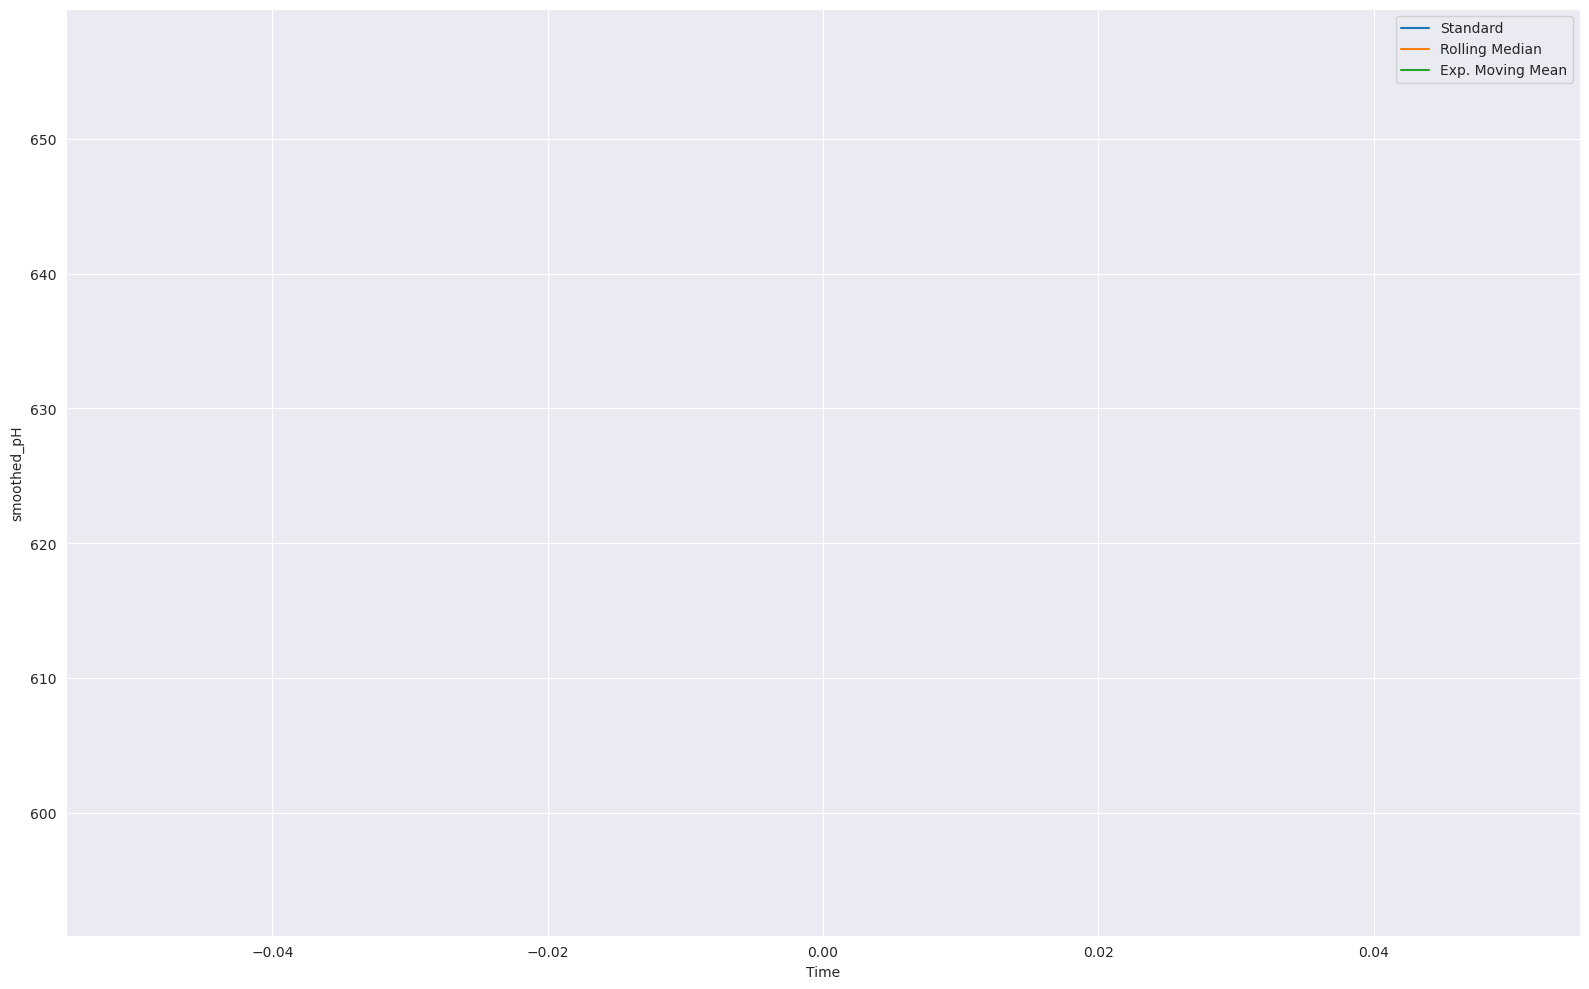

8671    0.0
Name: Time, dtype: float64


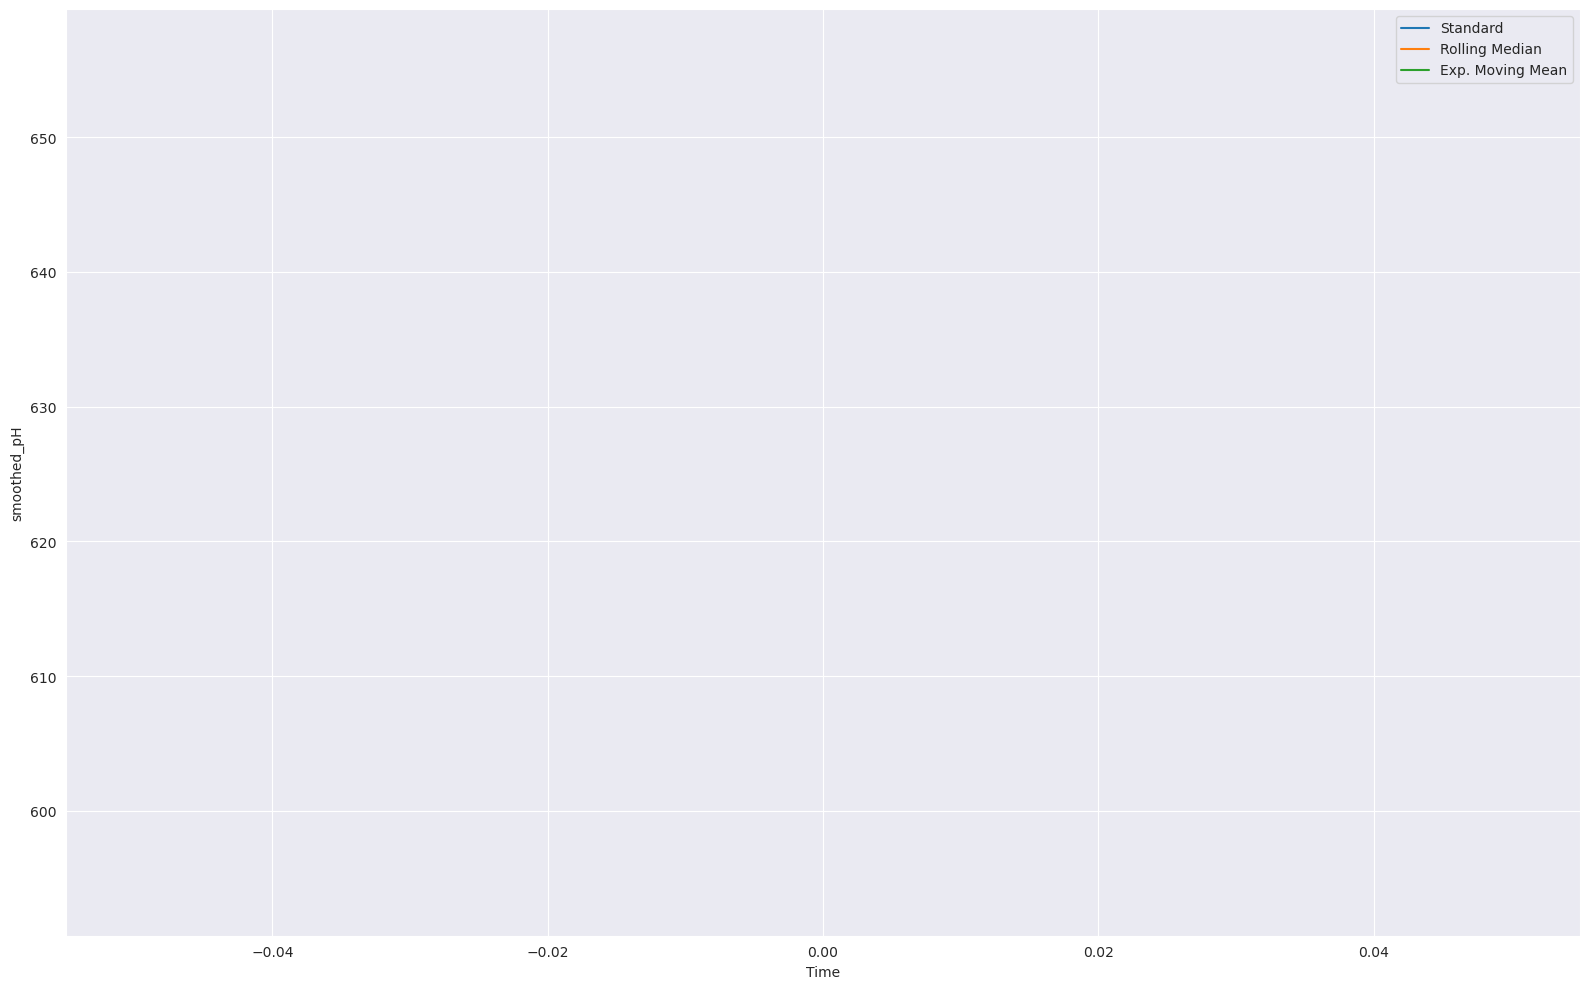

8674    0.0
Name: Time, dtype: float64


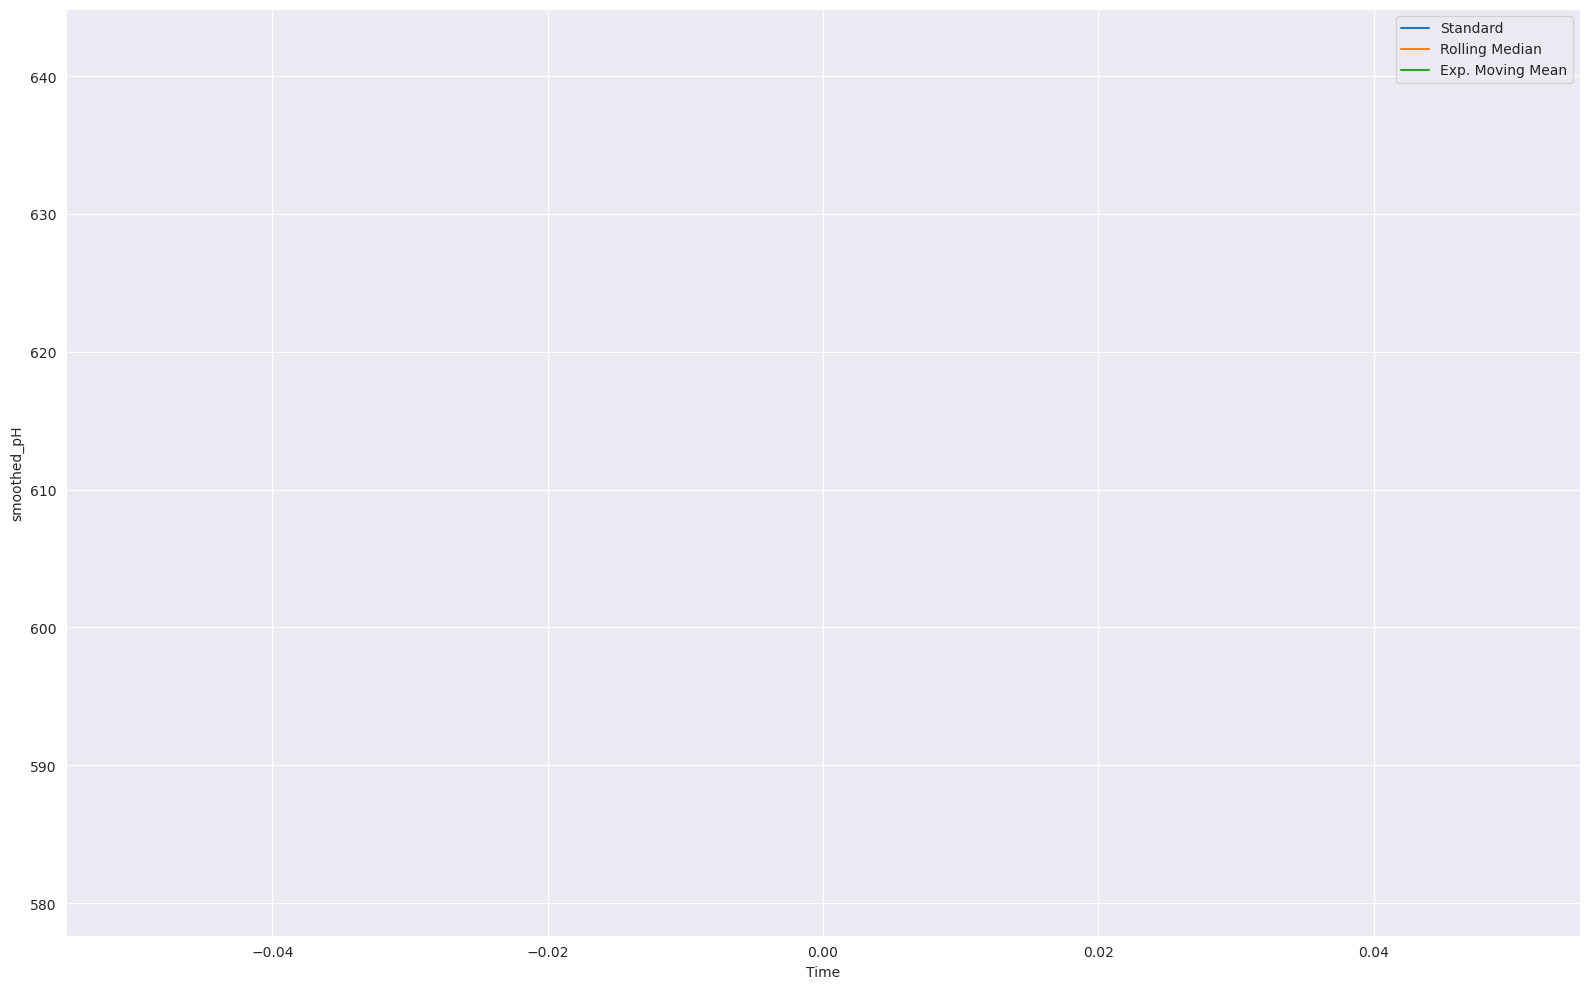

8677         0.0
8678         4.0
8679         7.0
8680        11.0
8681        14.0
          ...   
16508    27358.0
16509    27361.0
16510    27365.0
16511    27368.0
16512    27372.0
Name: Time, Length: 7836, dtype: float64


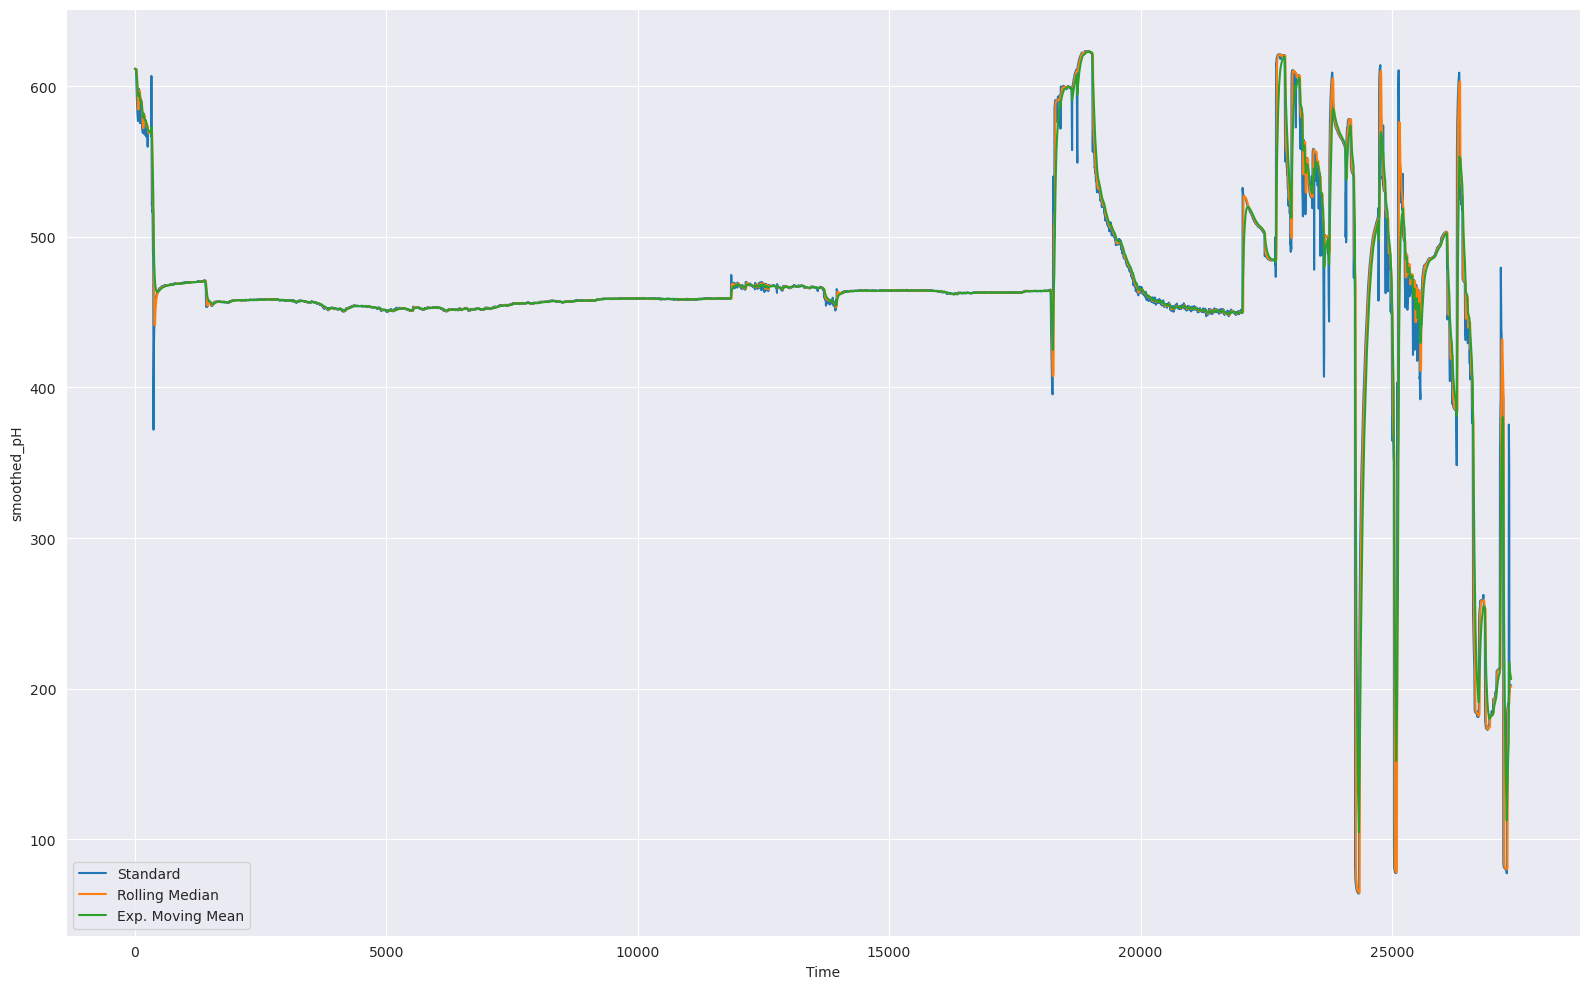

16515      0.0
16516      3.0
16517      7.0
16518     10.0
16519     14.0
16520     17.0
16521     21.0
16522     24.0
16523     28.0
16524     31.0
16525     35.0
16526     38.0
16527     42.0
16528     45.0
16529     49.0
16530     52.0
16531     56.0
16532     59.0
16533     63.0
16534     66.0
16535     70.0
16536     73.0
16537     77.0
16538     80.0
16539     84.0
16540     87.0
16541     91.0
16542     94.0
16543     98.0
16544    101.0
16545    105.0
16546    108.0
16547    112.0
16548    115.0
Name: Time, dtype: float64


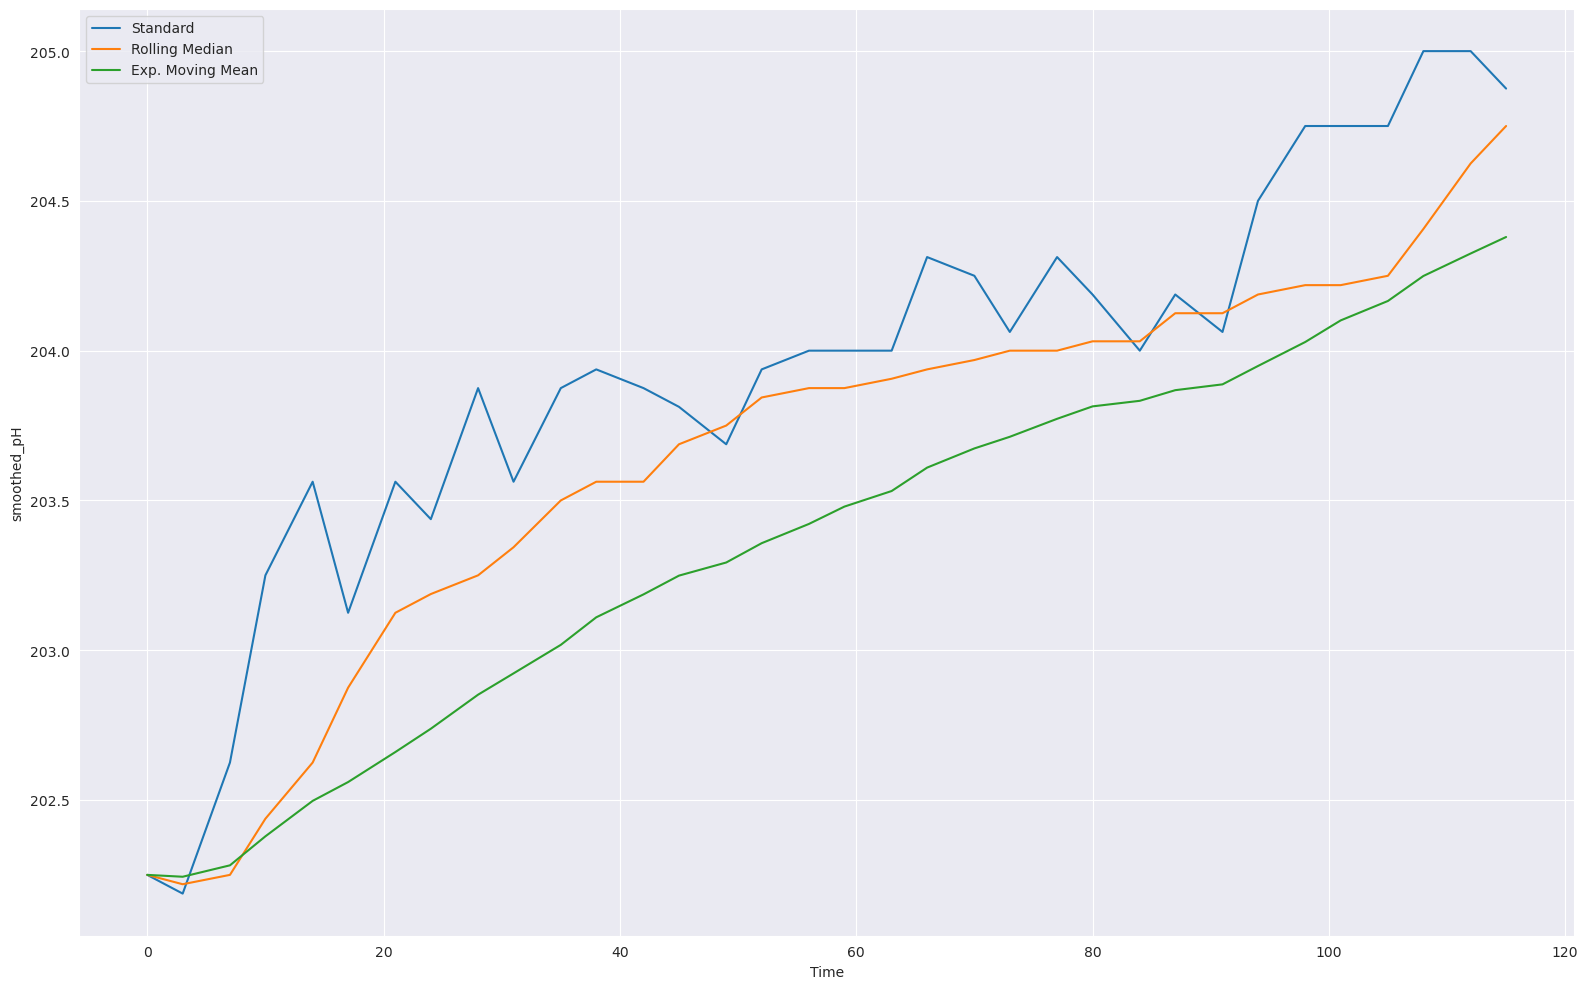

16551       0.0
16552       4.0
16553       7.0
16554      10.0
16555      14.0
          ...  
17923    4780.0
17924    4784.0
17925    4787.0
17926    4791.0
17927    4794.0
Name: Time, Length: 1377, dtype: float64


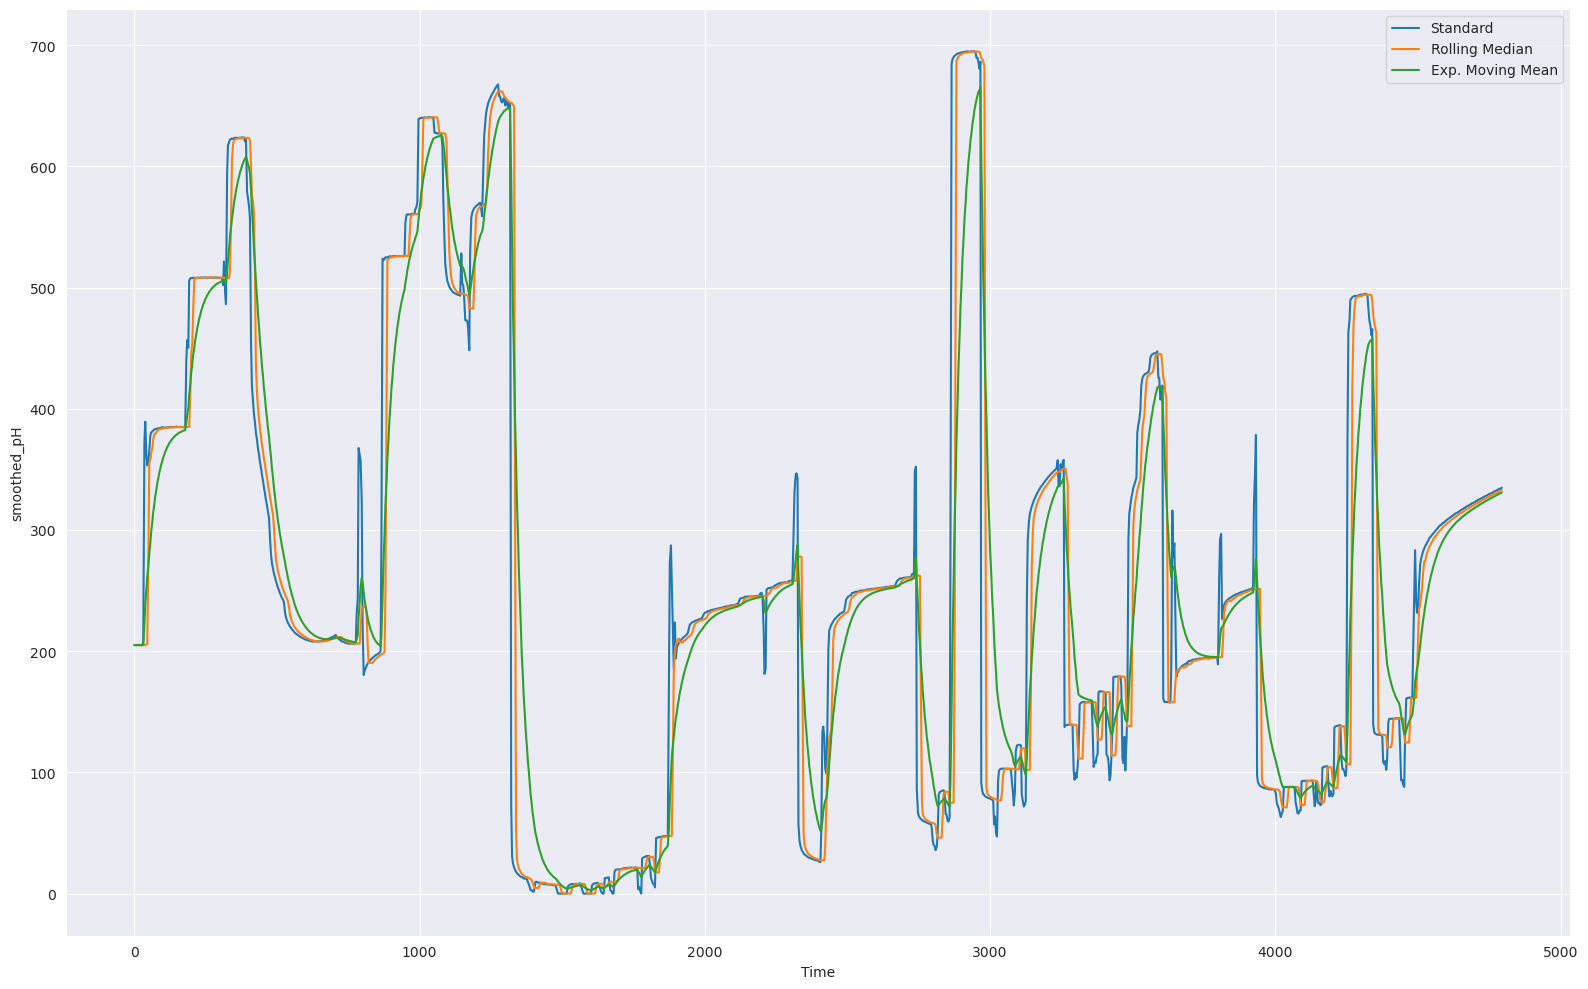

17930       0.0
17931       4.0
17932       7.0
17933      11.0
17934      14.0
          ...  
18429    1740.0
18430    1744.0
18431    1747.0
18432    1751.0
18433    1754.0
Name: Time, Length: 504, dtype: float64


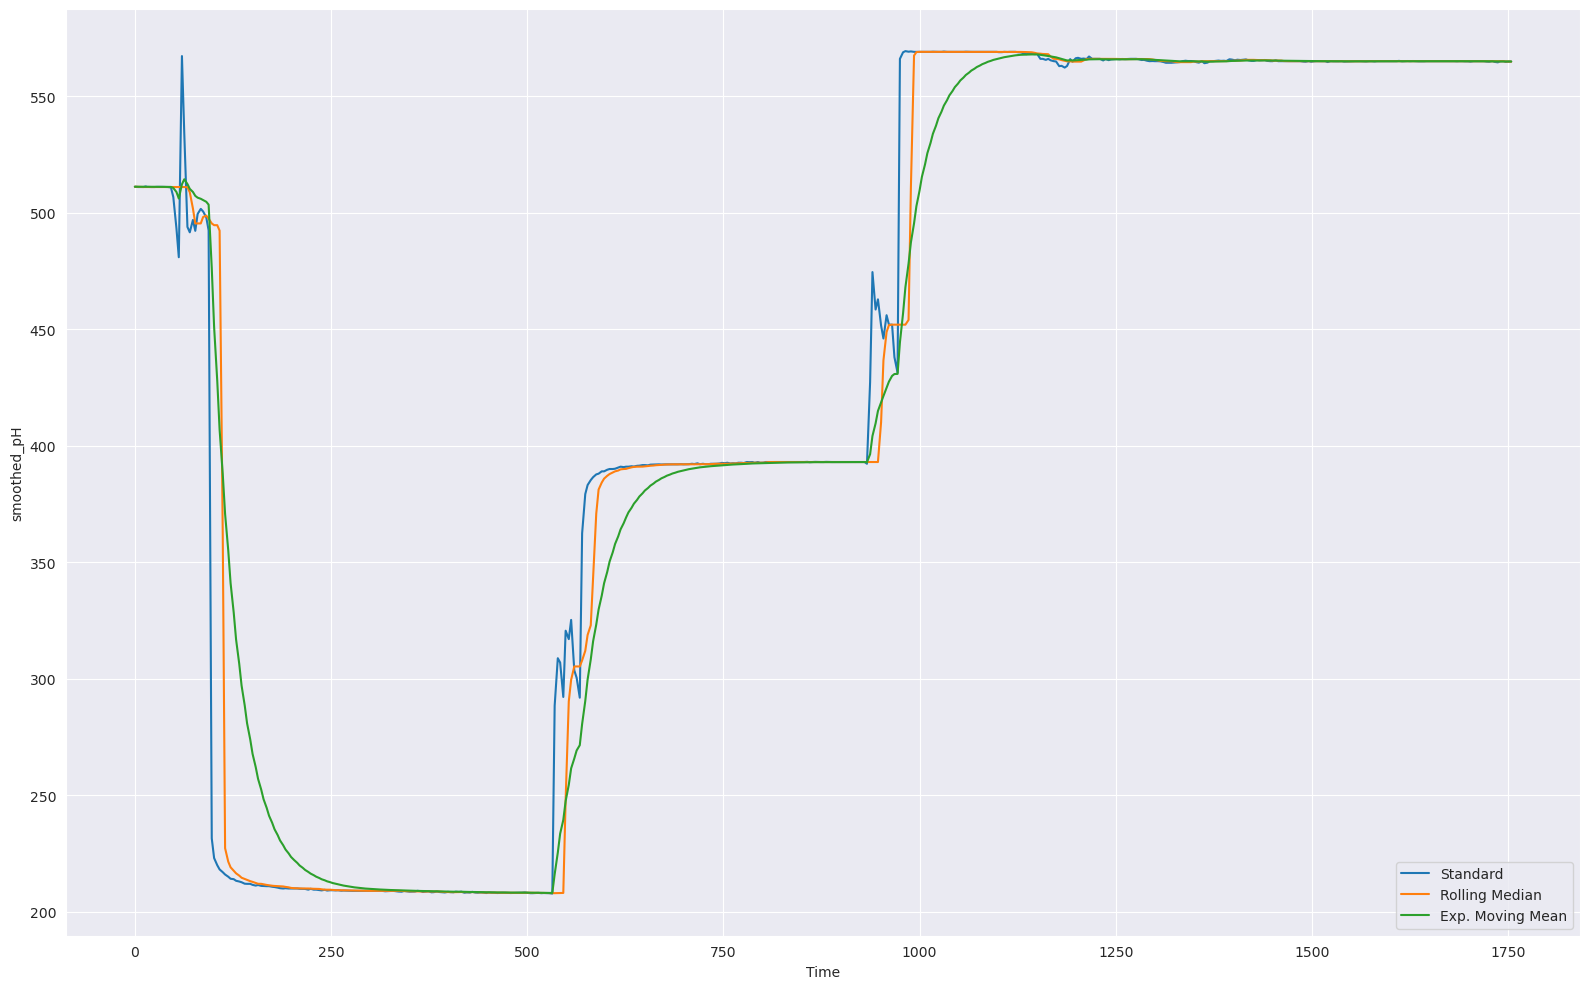

18436       0.0
18437       4.0
18438       7.0
18439      11.0
18440      14.0
          ...  
19317    3078.0
19318    3082.0
19319    3085.0
19320    3089.0
19321    3092.0
Name: Time, Length: 886, dtype: float64


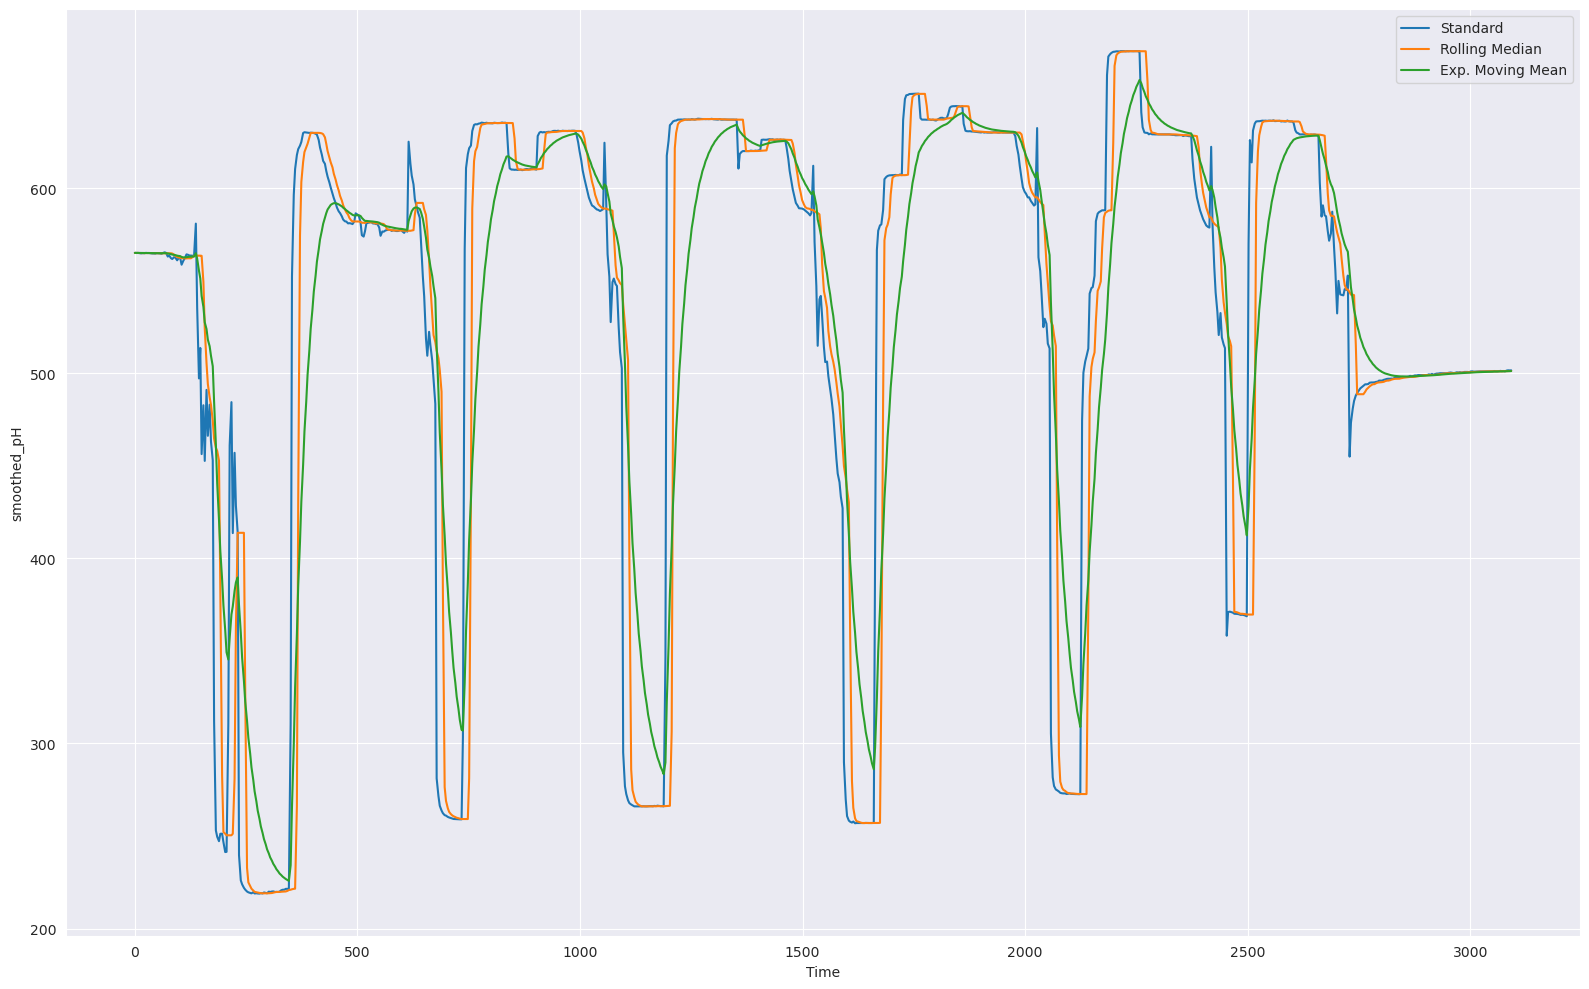

19324       0.0
19325       3.0
19326       7.0
19327      10.0
19328      14.0
          ...  
21003    5866.0
21004    5869.0
21005    5873.0
21006    5876.0
21007    5880.0
Name: Time, Length: 1684, dtype: float64


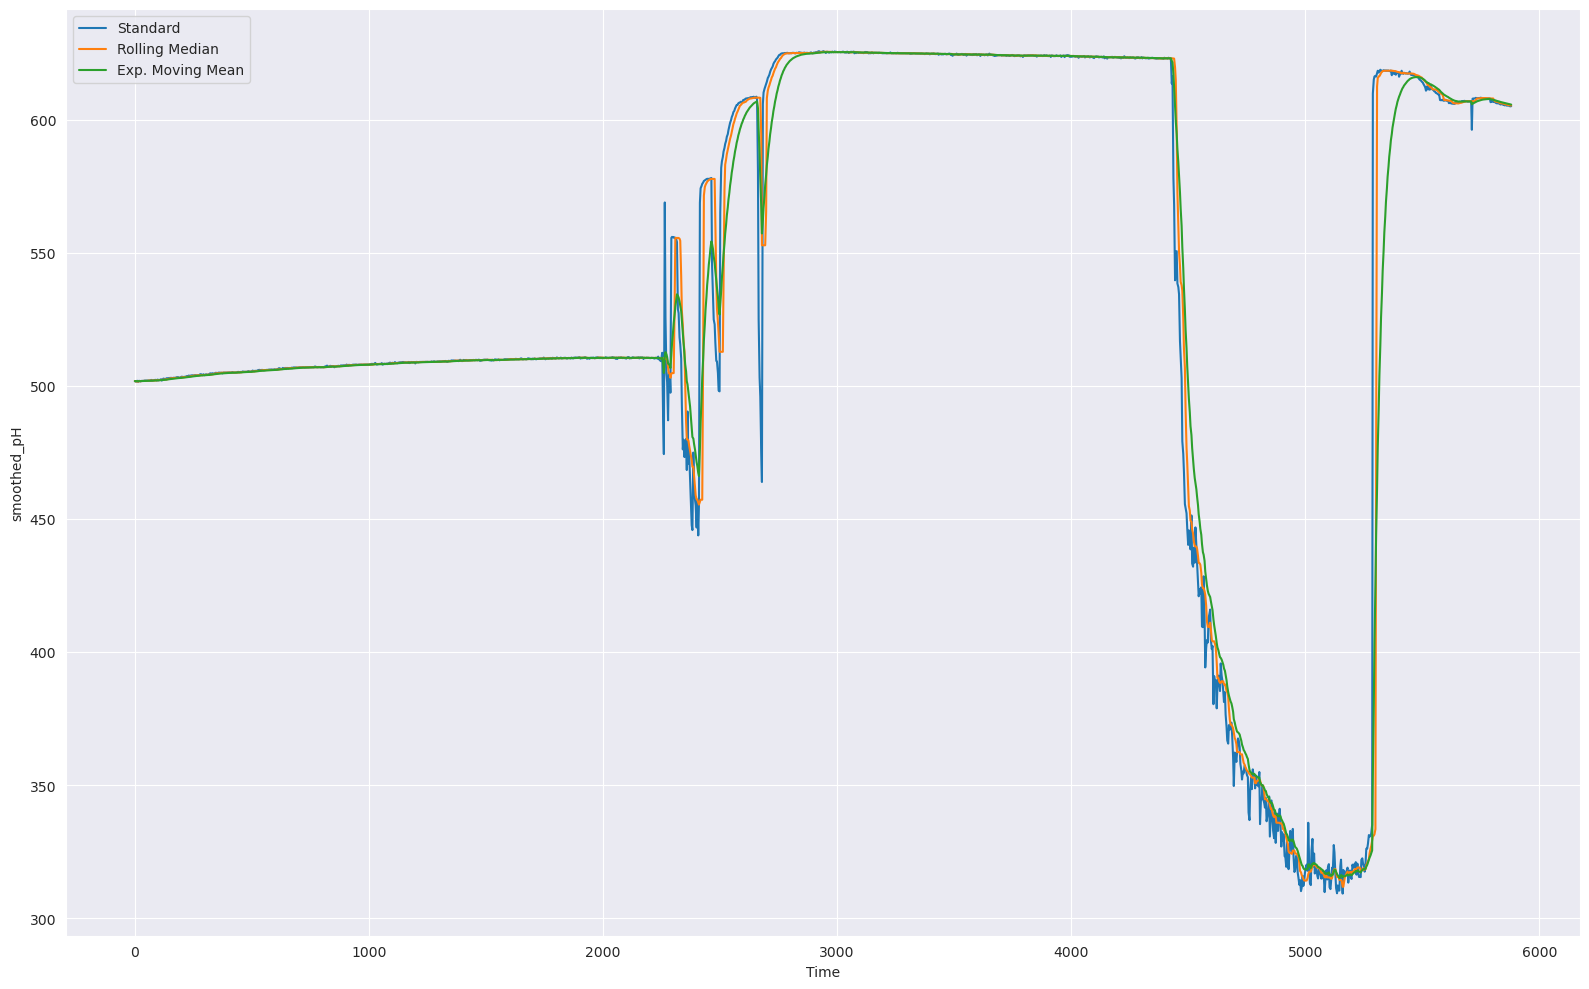

21010     0.0
21011     3.0
21012     7.0
21013    10.0
21014    14.0
21015    17.0
21016    21.0
21017    24.0
Name: Time, dtype: float64


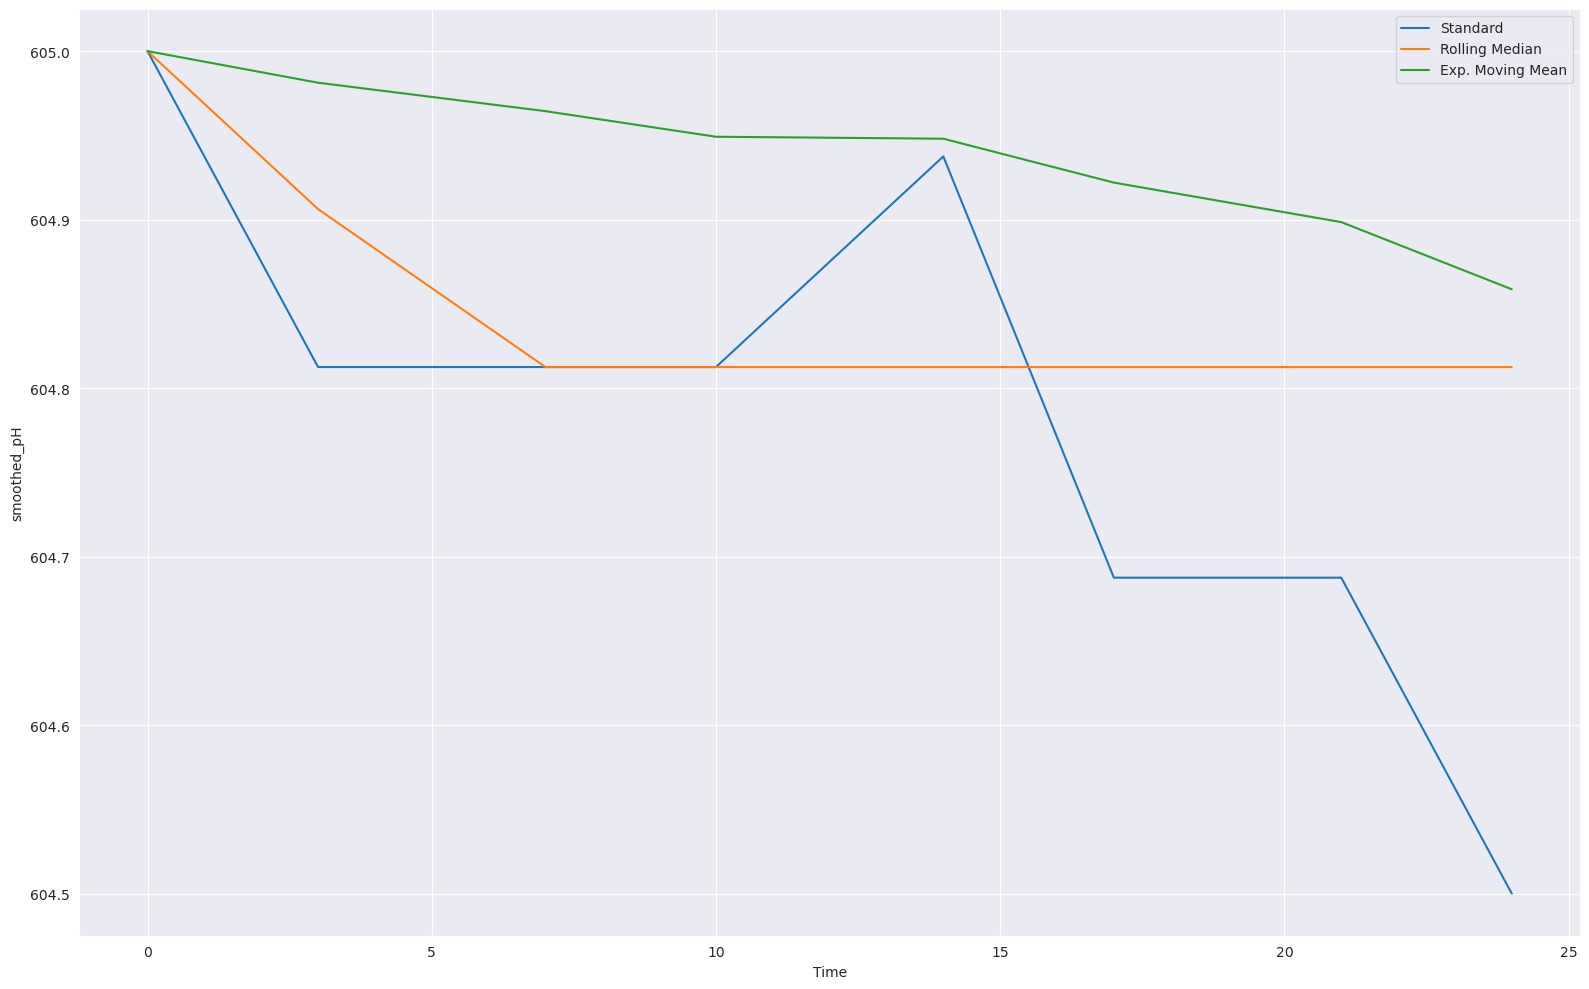

KeyError: np.int64(21020)

In [113]:
midx = np.where(df['Time'].isnull())[0]
midx
for i, n in enumerate(midx[:-1]):
    m = midx[i + 1]
    dfs = df[n + 1:m - 1]
    dfs.loc[:, 'Time'] = pd.to_datetime(dfs.loc[:, 'Time'], format='%Y-%m-%d %H:%M:%S')

    dt0 = dfs.loc[n + 1, 'Time']
    dt = dfs['Time'] - dt0
    dt = dt.dt.total_seconds()
    print(dt)
    yph = dfs['smoothed_pH']
    yph = dfs['analog_pH']
    ynh3 = dfs['smoothed_NH3']

    yphr = yph.rolling(10, min_periods=1).median()
    yphe = yph.ewm(alpha=0.1, adjust=False).mean()


    fig, ax = plt.subplots(figsize=(16, 10))
    ax.plot(dt, yph, label='Standard')
    ax.plot(dt, yphr, label='Rolling Median')
    ax.plot(dt, yphe, label='Exp. Moving Mean')
    ax.set_xlabel('Time')
    ax.set_ylabel('smoothed_pH')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'PumpControl/img/{y_label}-segment-{i}.png')
    plt.show()

1           0.0
2           4.0
3           7.0
4          11.0
5          14.0
         ...   
3548    12393.0
3549    12396.0
3550    12400.0
3551    12403.0
3552    12407.0
Name: Time, Length: 3552, dtype: float64


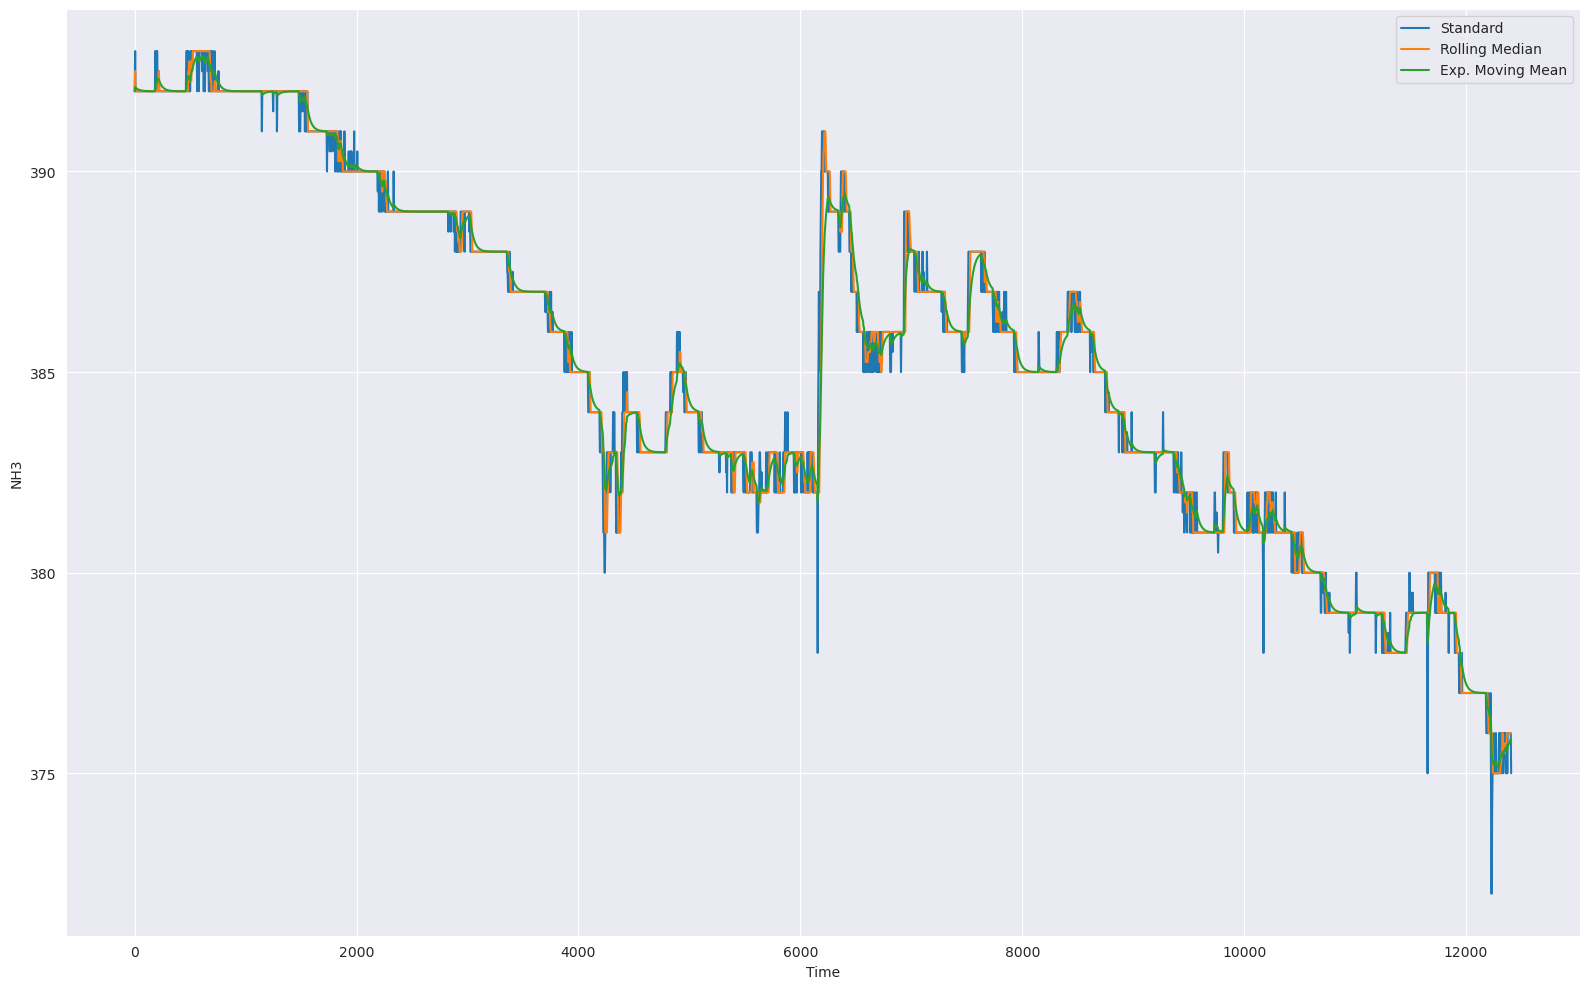

3555        0.0
3556        4.0
3557        7.0
3558       11.0
3559       14.0
         ...   
8652    17804.0
8653    17808.0
8654    17811.0
8655    17815.0
8656    17818.0
Name: Time, Length: 5102, dtype: float64


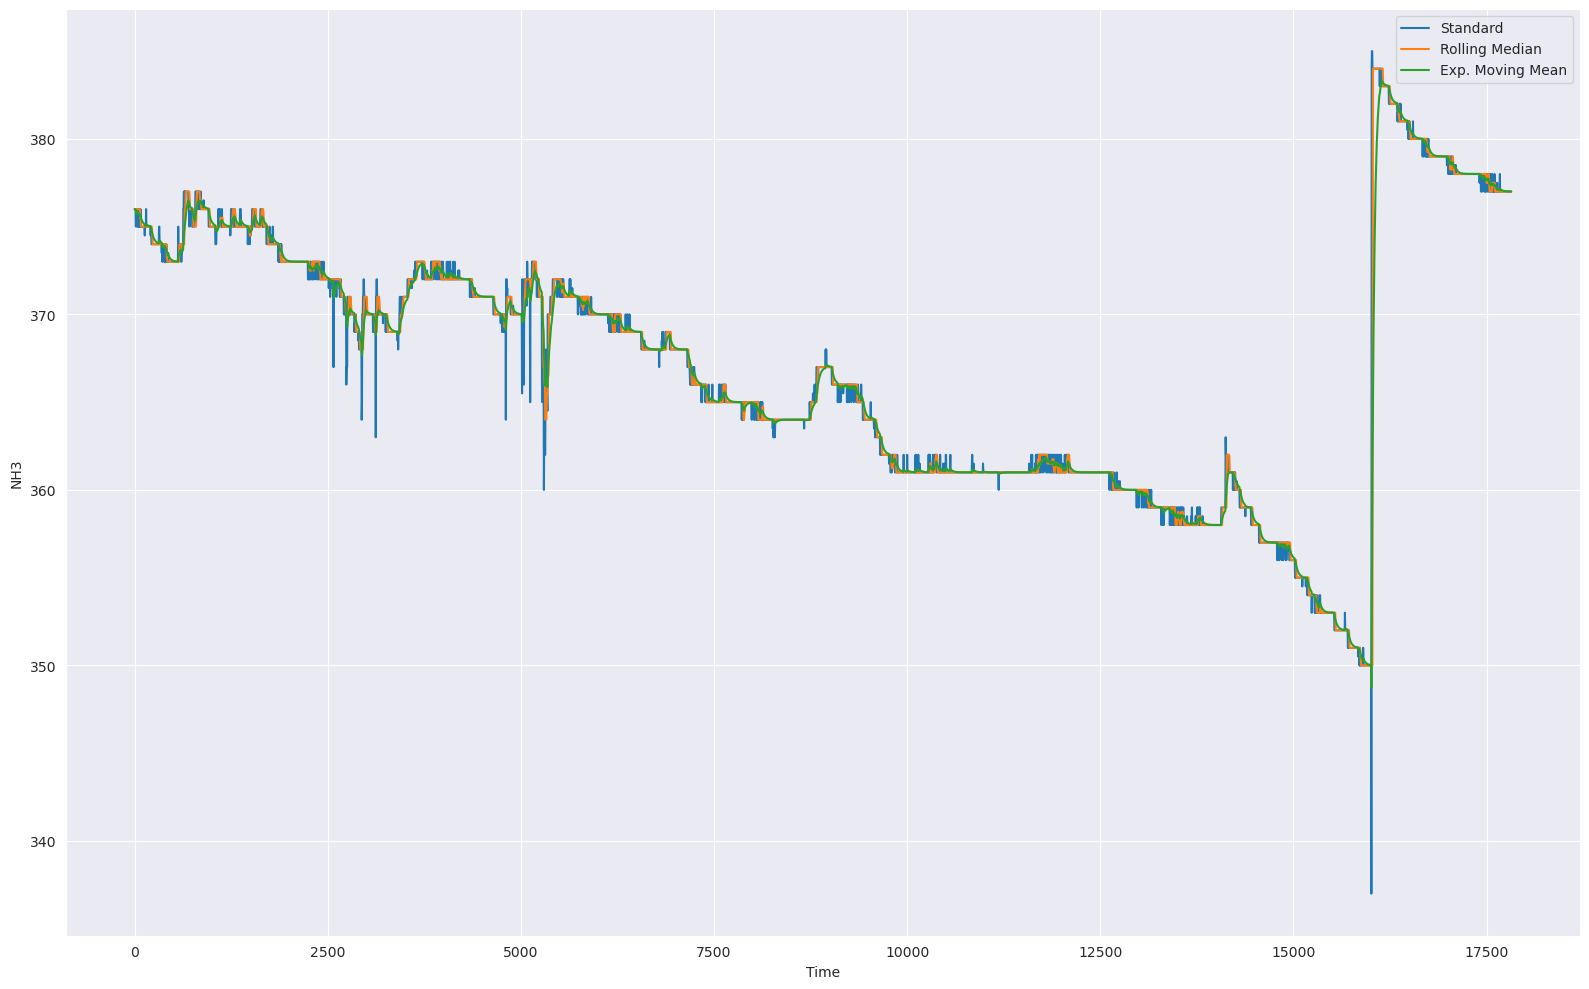

8659    0.0
Name: Time, dtype: float64


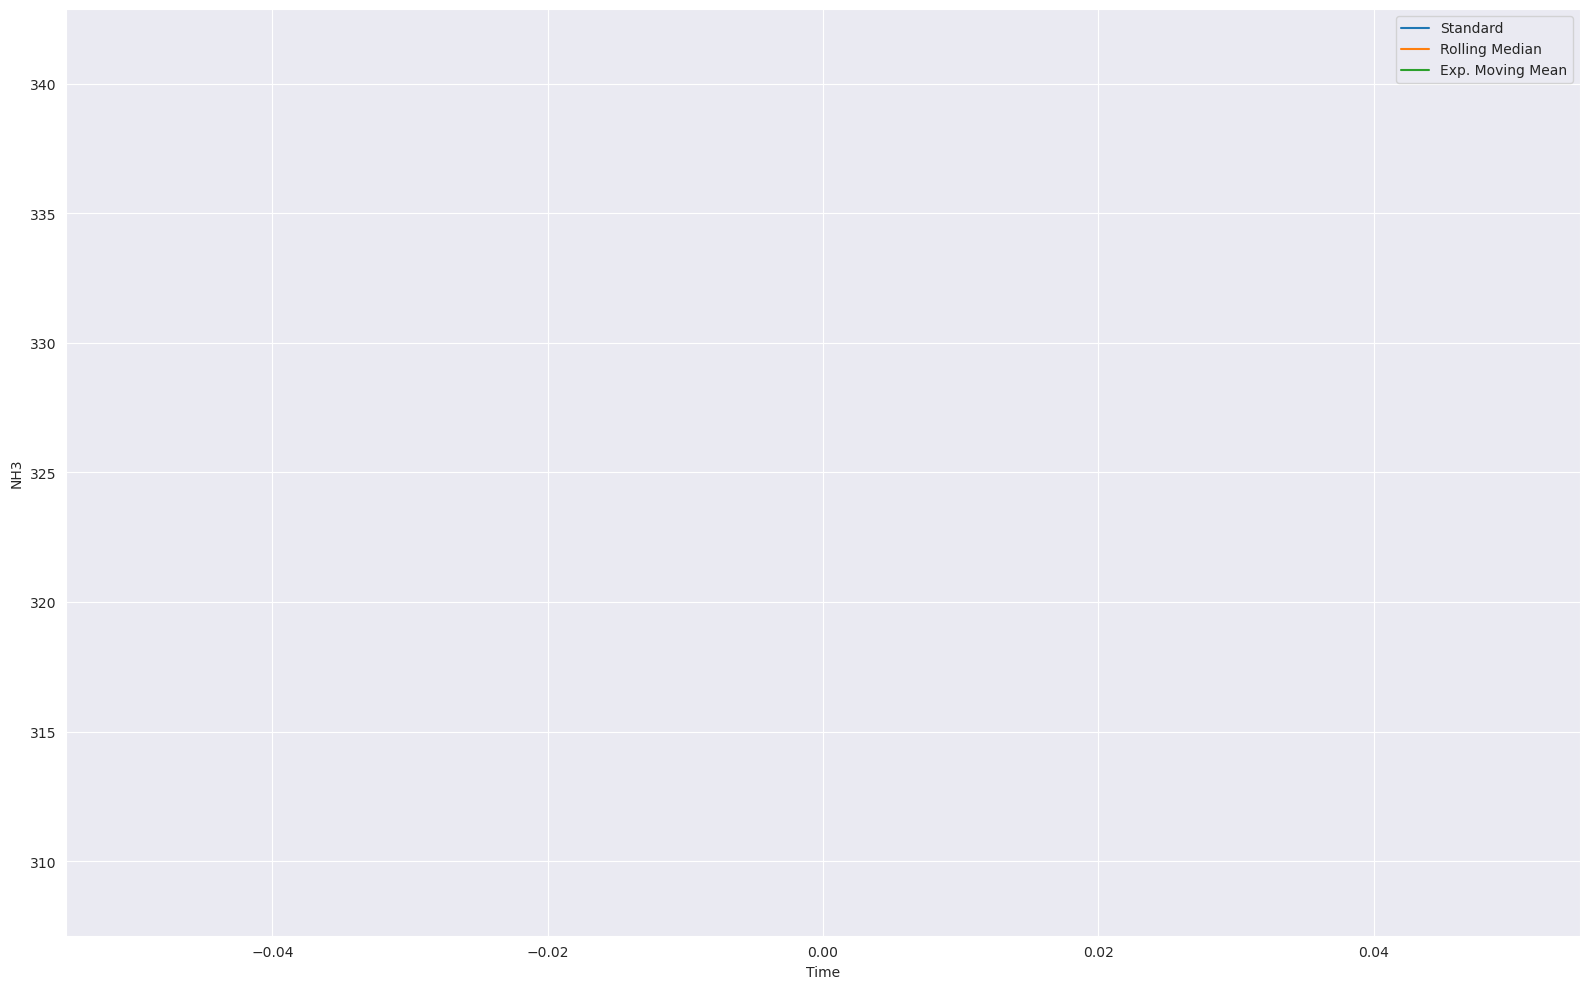

8662    0.0
Name: Time, dtype: float64


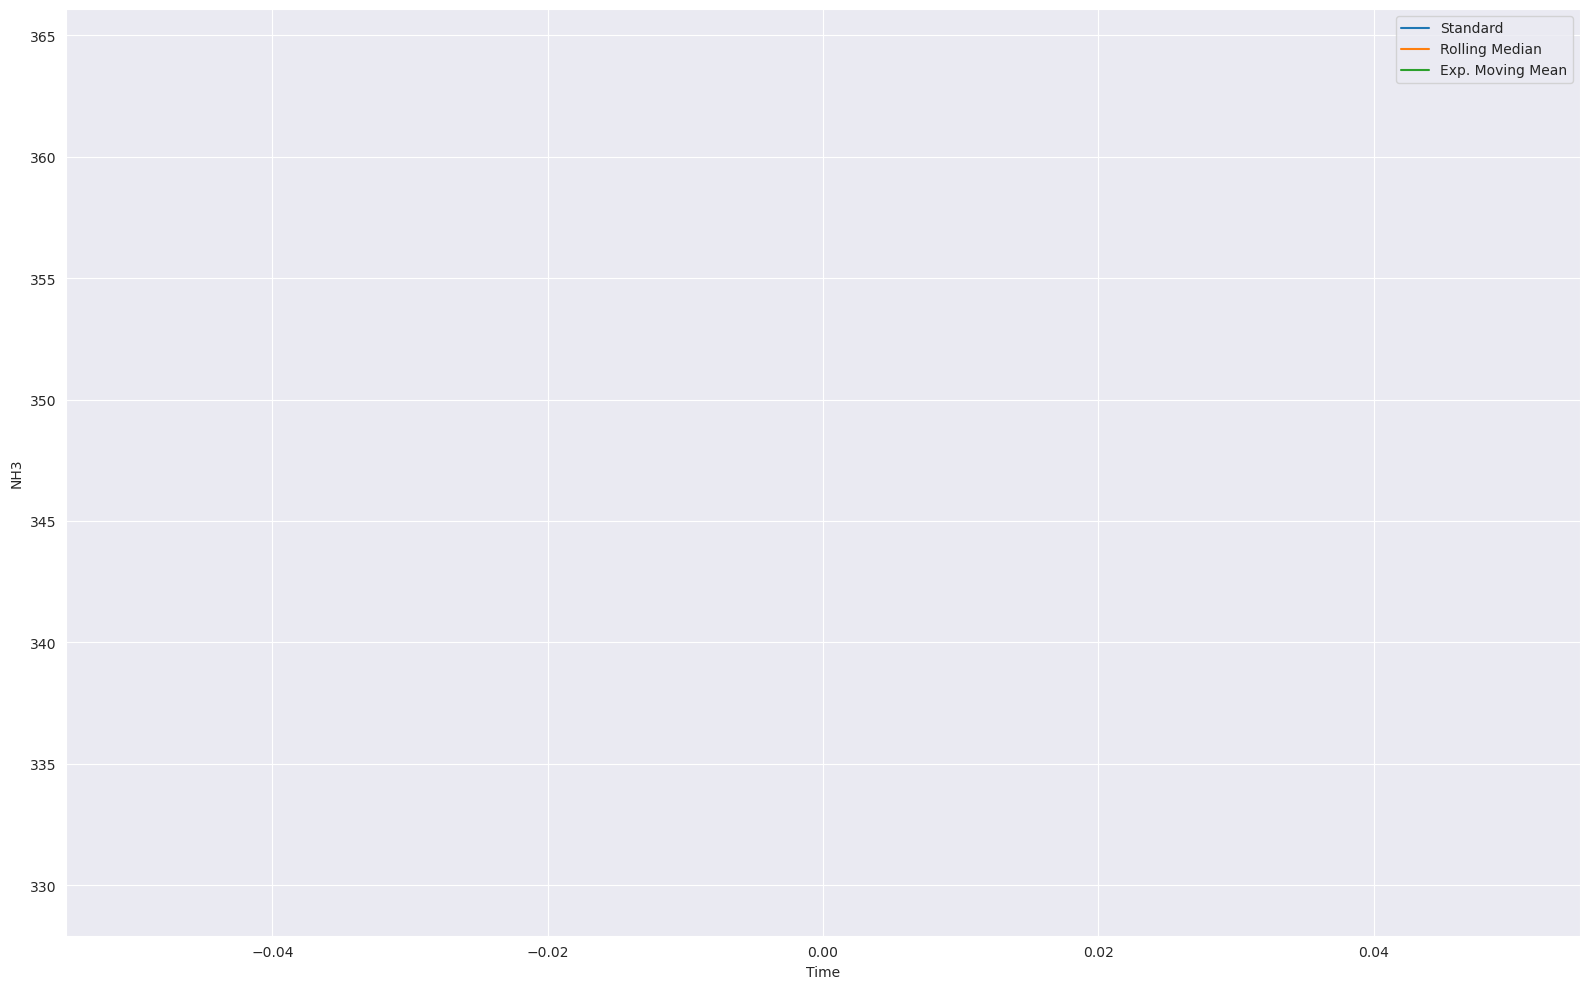

8665    0.0
Name: Time, dtype: float64


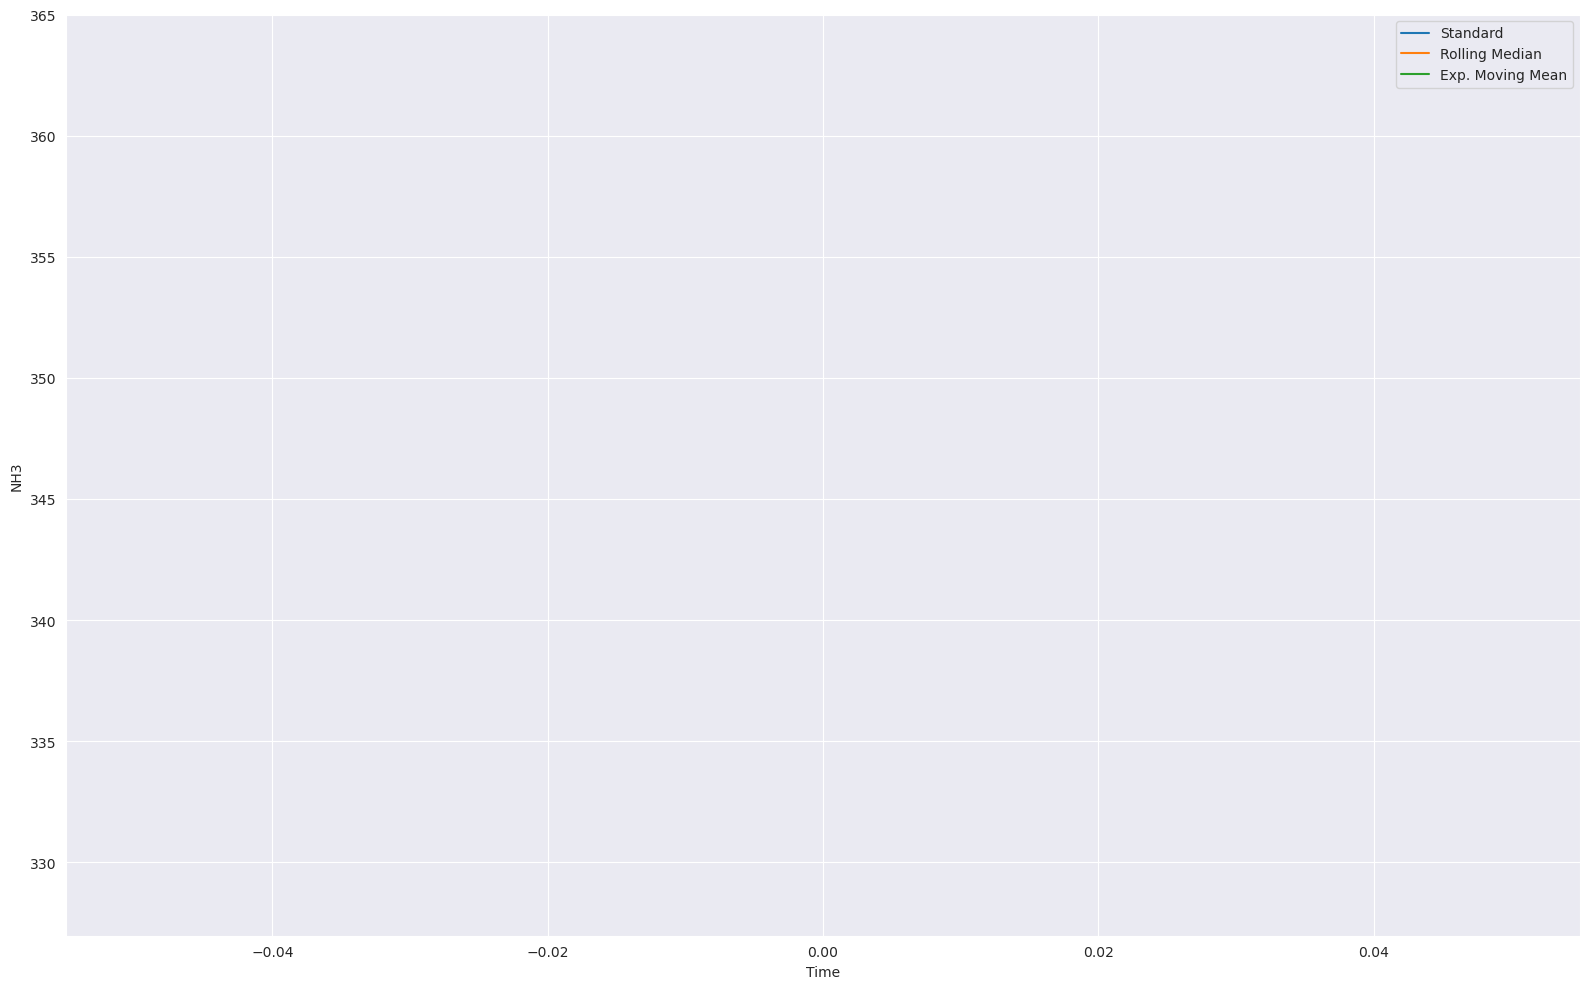

8668    0.0
Name: Time, dtype: float64


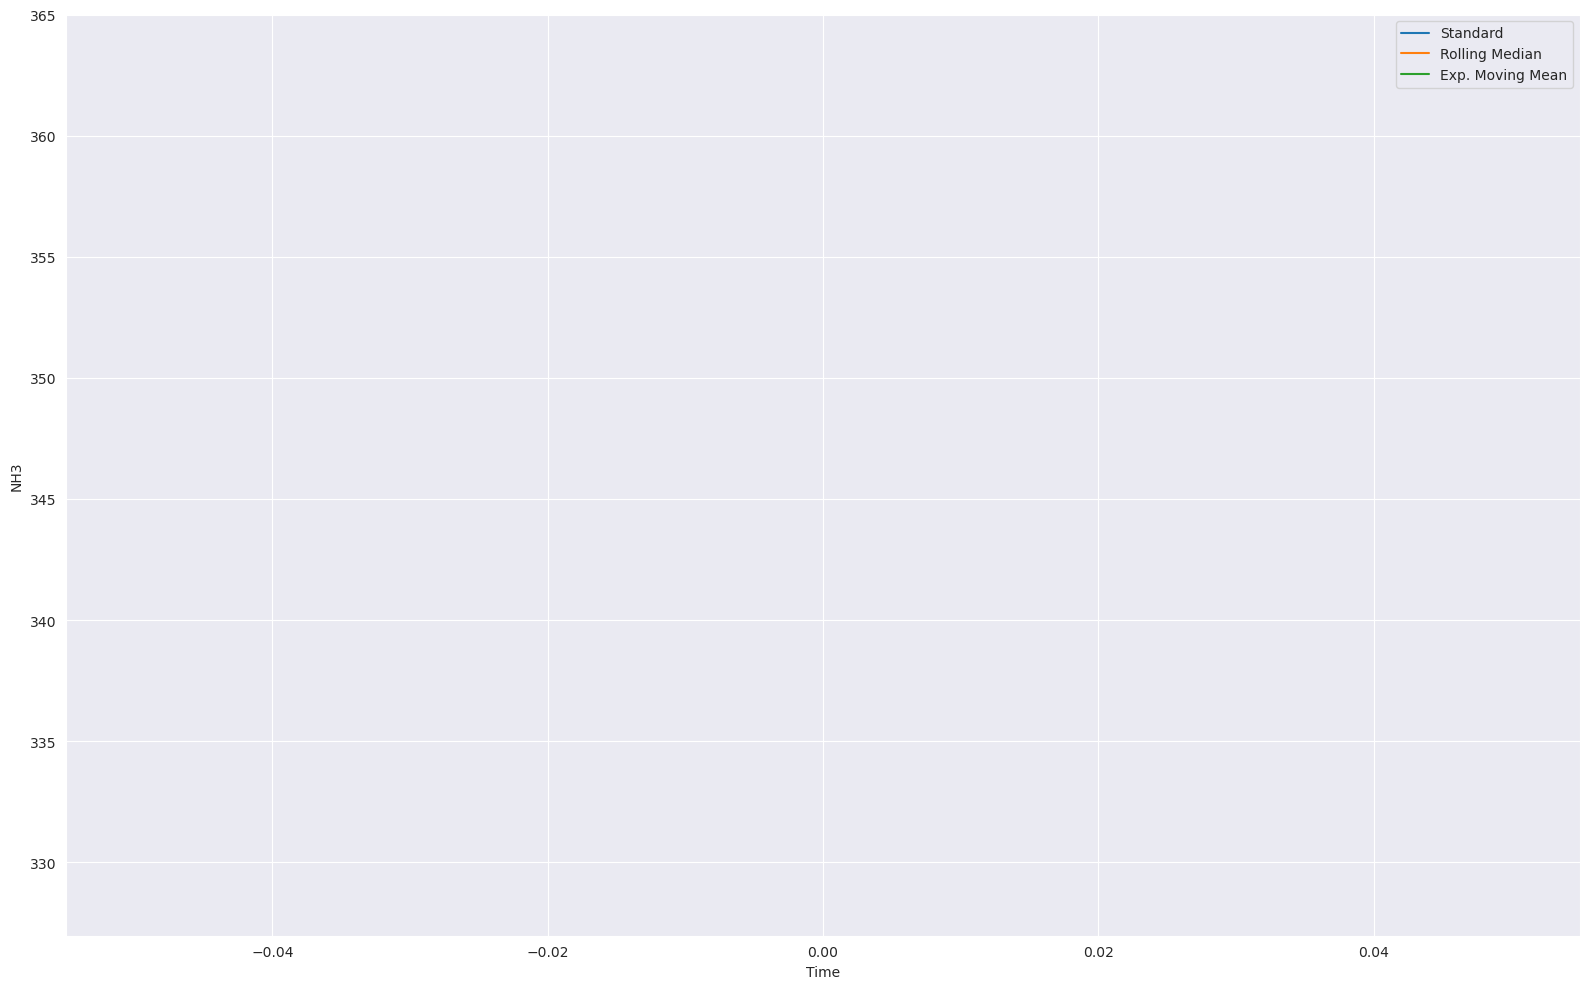

8671    0.0
Name: Time, dtype: float64


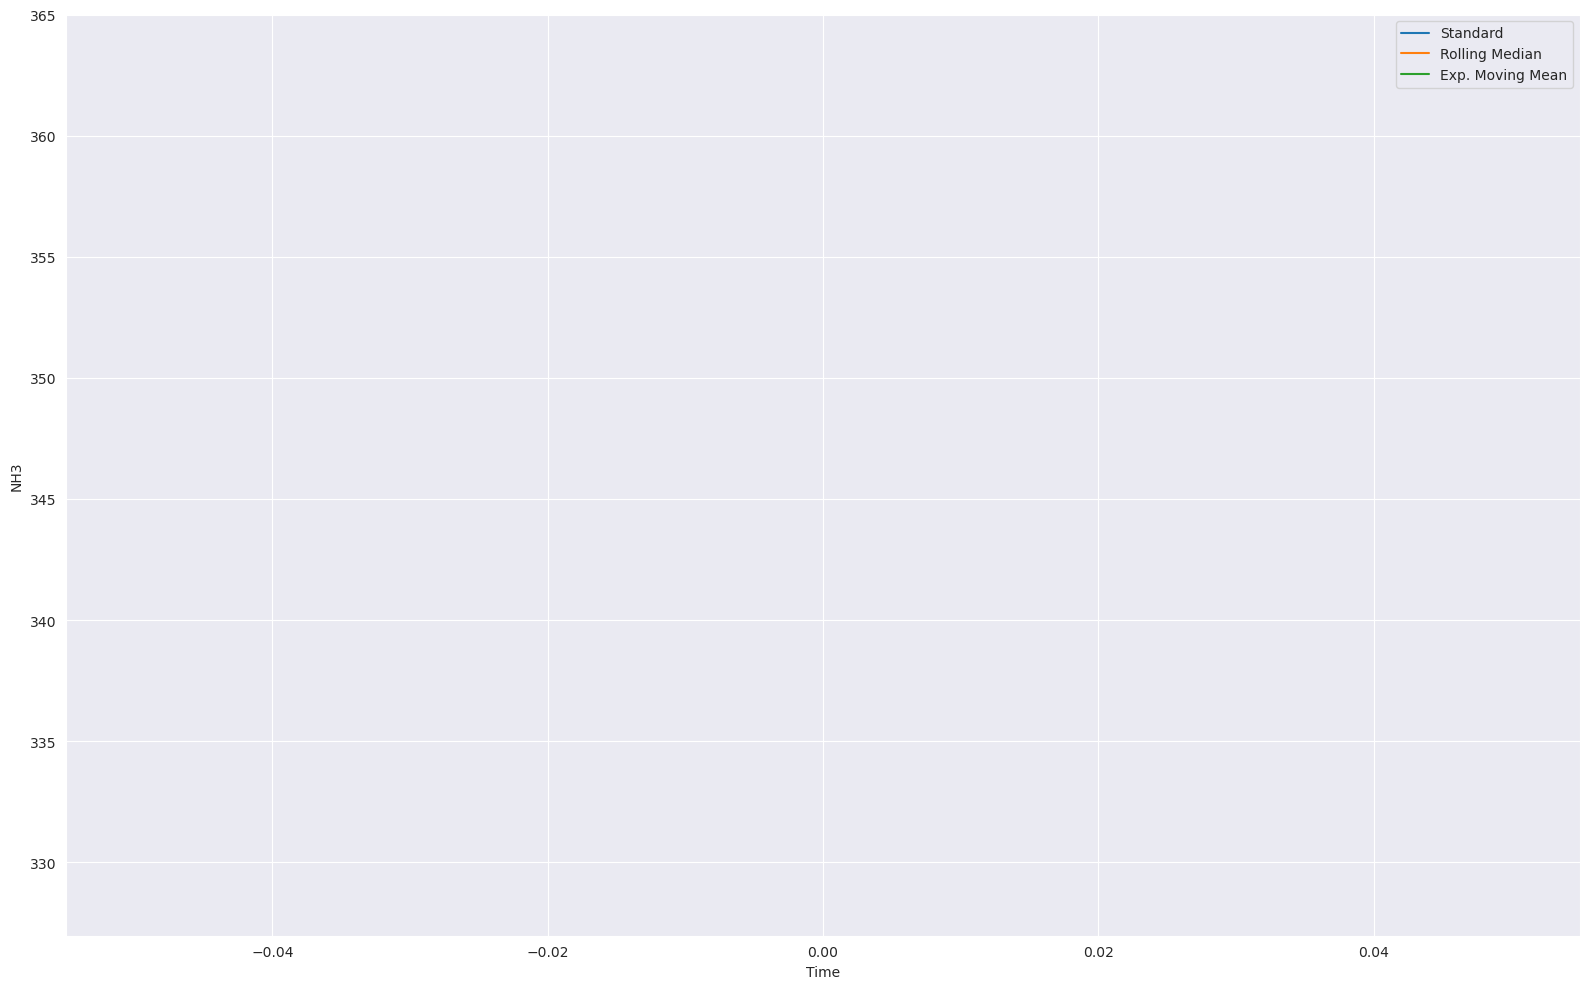

8674    0.0
Name: Time, dtype: float64


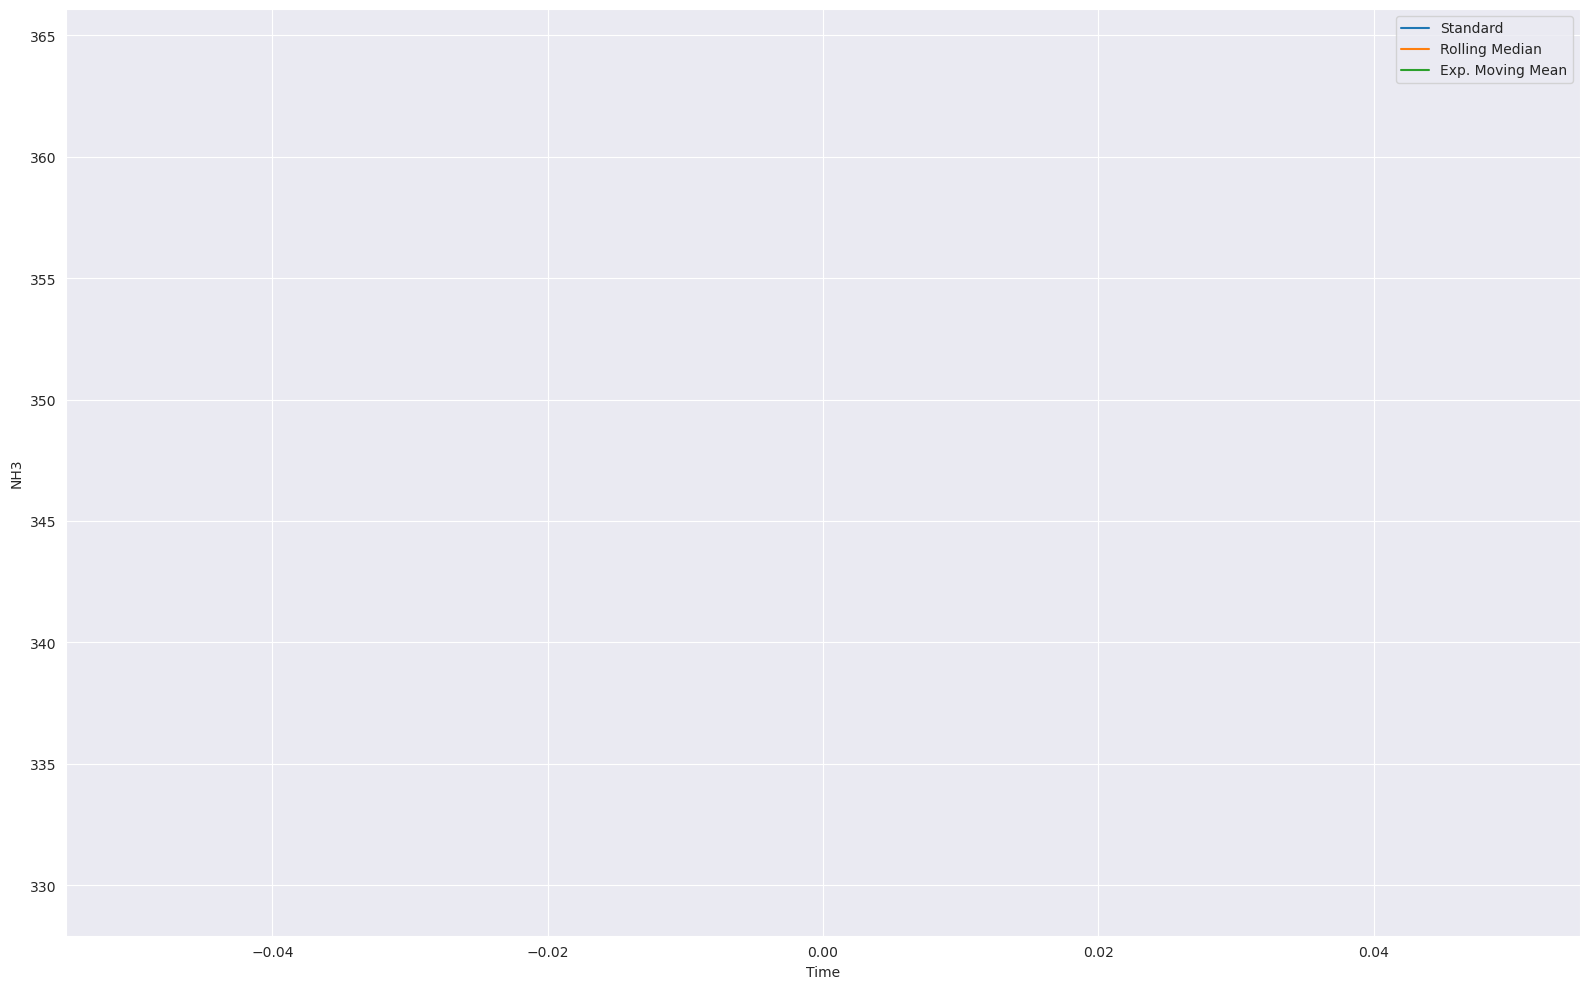

8677         0.0
8678         4.0
8679         7.0
8680        11.0
8681        14.0
          ...   
16508    27358.0
16509    27361.0
16510    27365.0
16511    27368.0
16512    27372.0
Name: Time, Length: 7836, dtype: float64


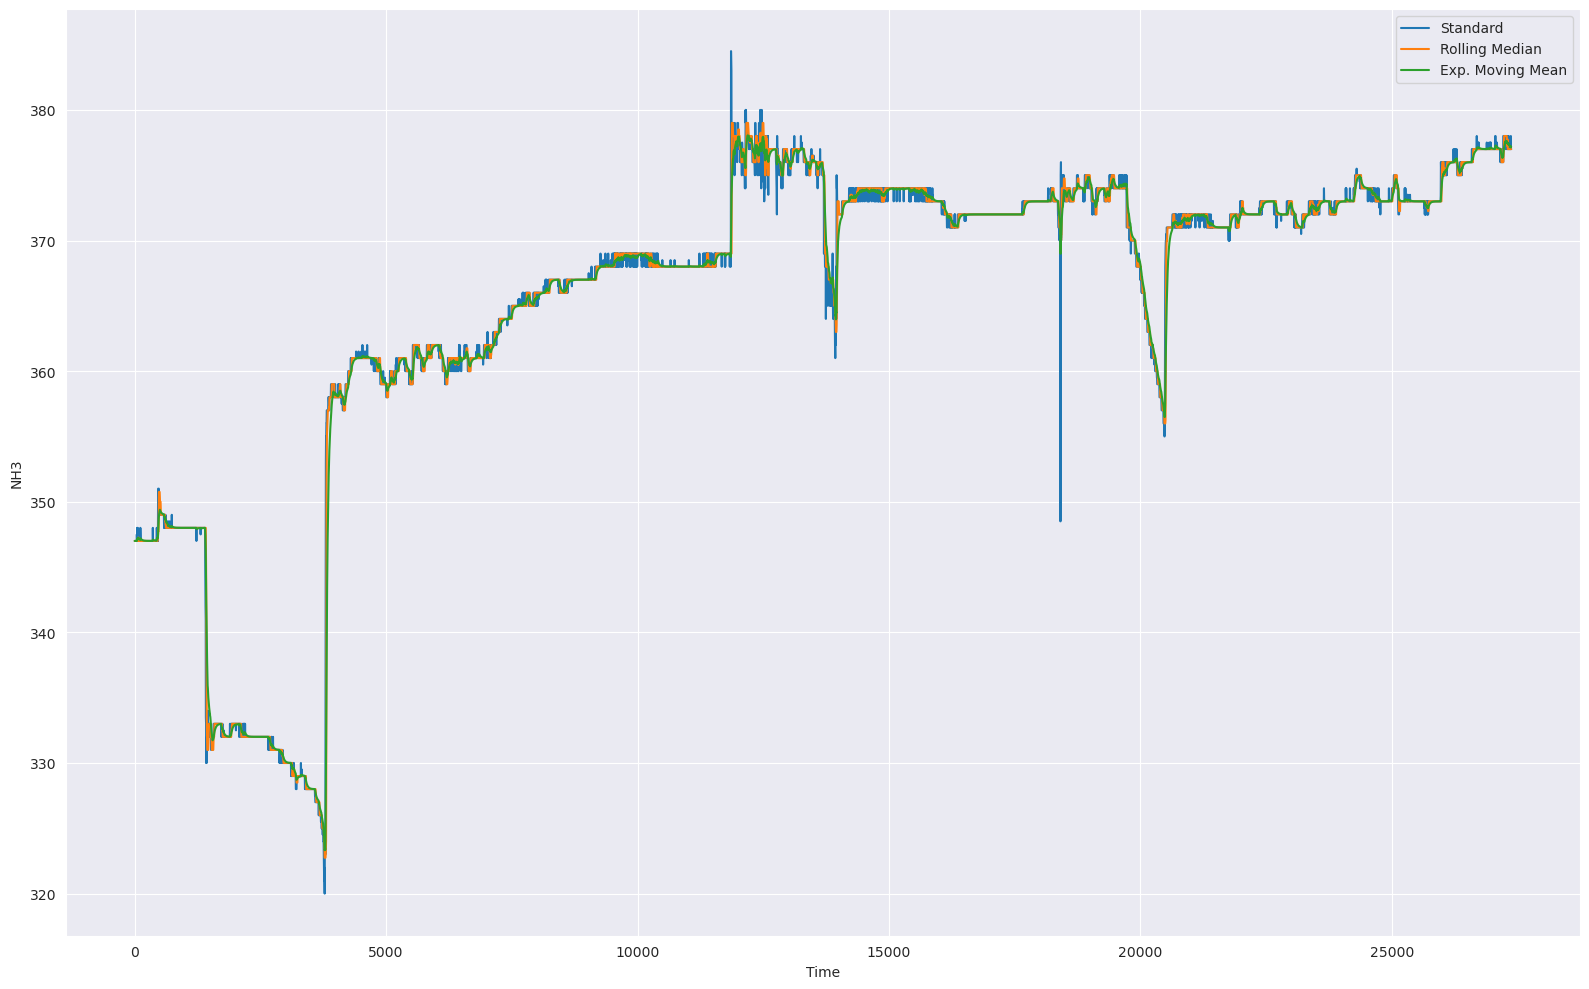

16515      0.0
16516      3.0
16517      7.0
16518     10.0
16519     14.0
16520     17.0
16521     21.0
16522     24.0
16523     28.0
16524     31.0
16525     35.0
16526     38.0
16527     42.0
16528     45.0
16529     49.0
16530     52.0
16531     56.0
16532     59.0
16533     63.0
16534     66.0
16535     70.0
16536     73.0
16537     77.0
16538     80.0
16539     84.0
16540     87.0
16541     91.0
16542     94.0
16543     98.0
16544    101.0
16545    105.0
16546    108.0
16547    112.0
16548    115.0
Name: Time, dtype: float64


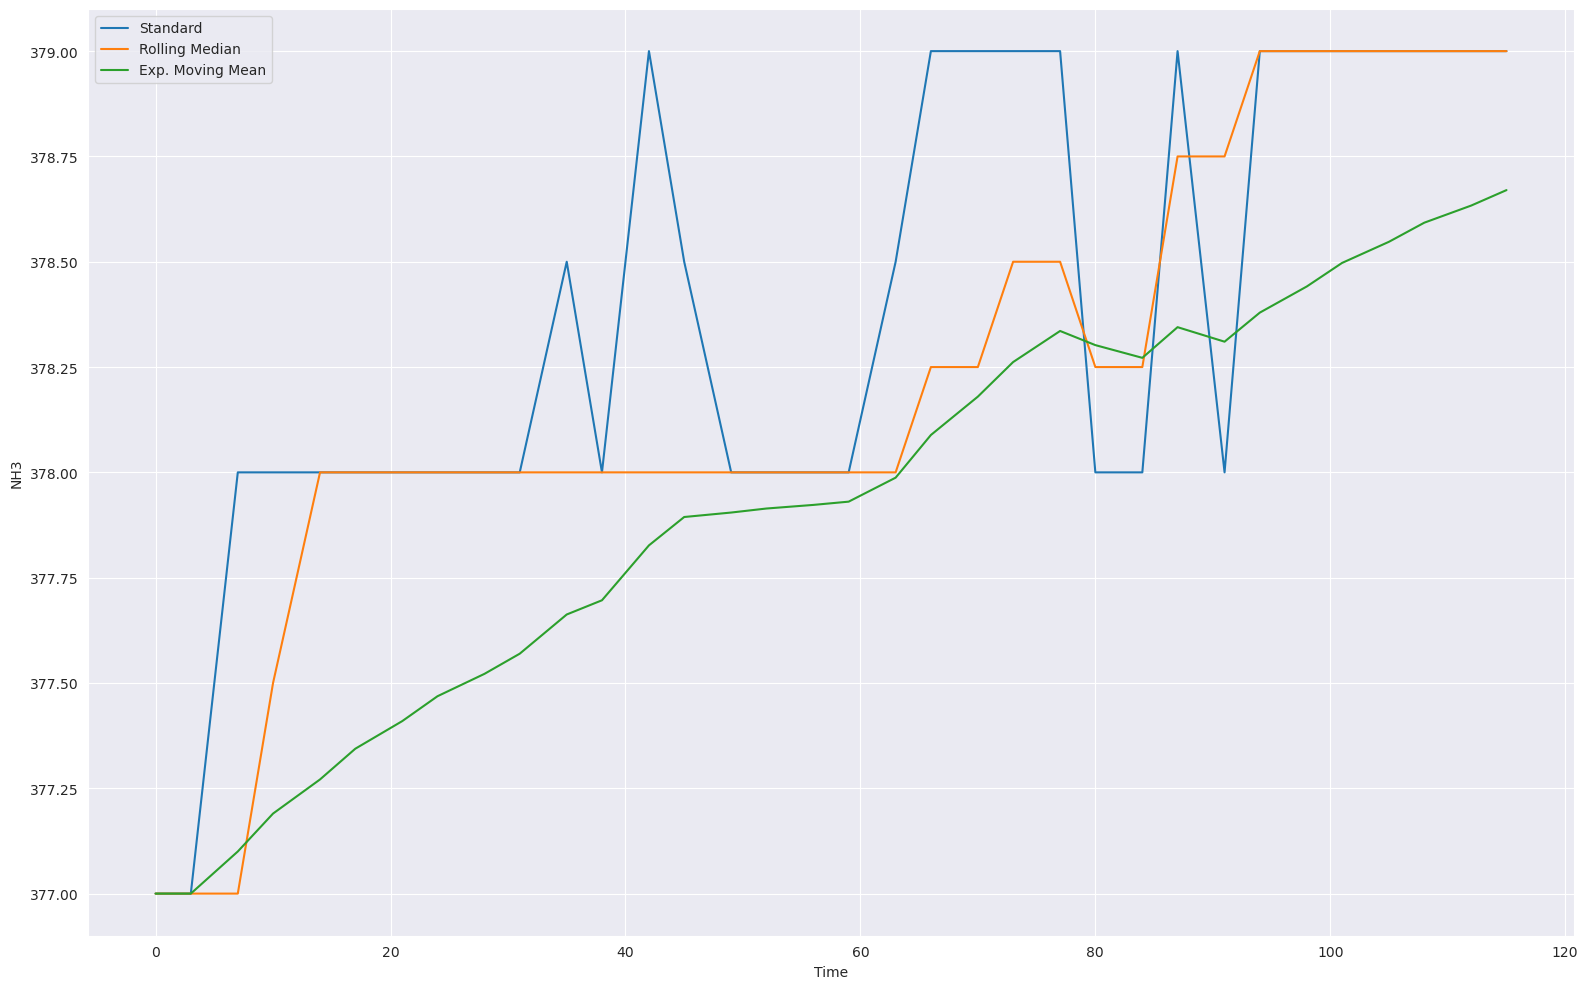

16551       0.0
16552       4.0
16553       7.0
16554      10.0
16555      14.0
          ...  
17923    4780.0
17924    4784.0
17925    4787.0
17926    4791.0
17927    4794.0
Name: Time, Length: 1377, dtype: float64


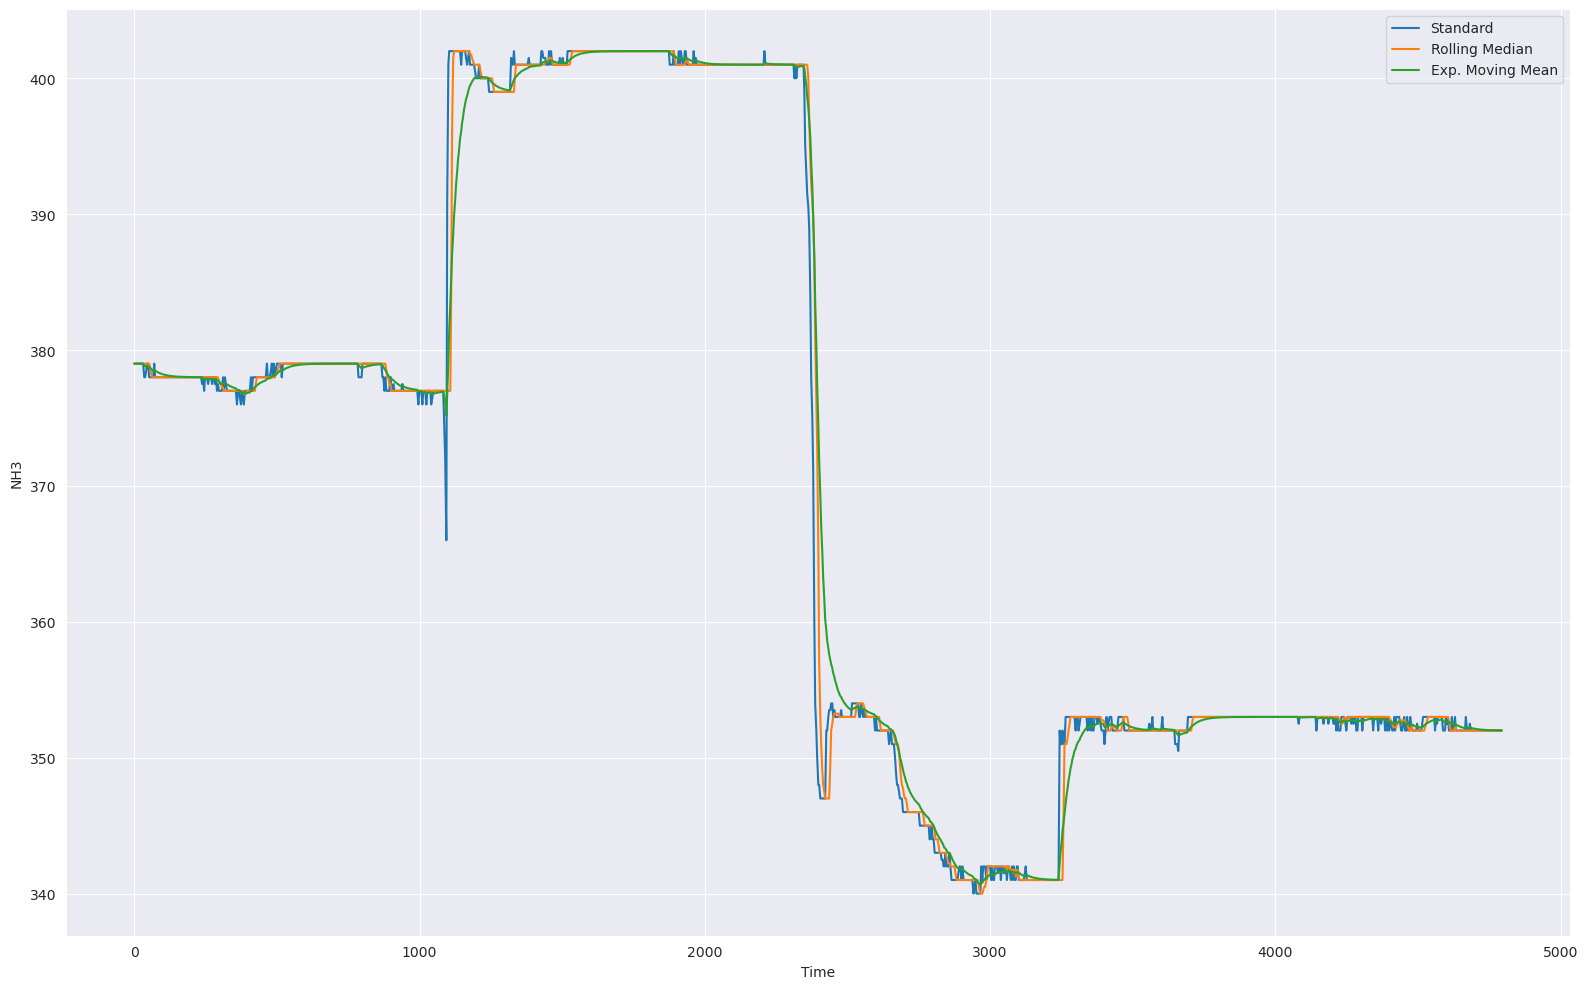

17930       0.0
17931       4.0
17932       7.0
17933      11.0
17934      14.0
          ...  
18429    1740.0
18430    1744.0
18431    1747.0
18432    1751.0
18433    1754.0
Name: Time, Length: 504, dtype: float64


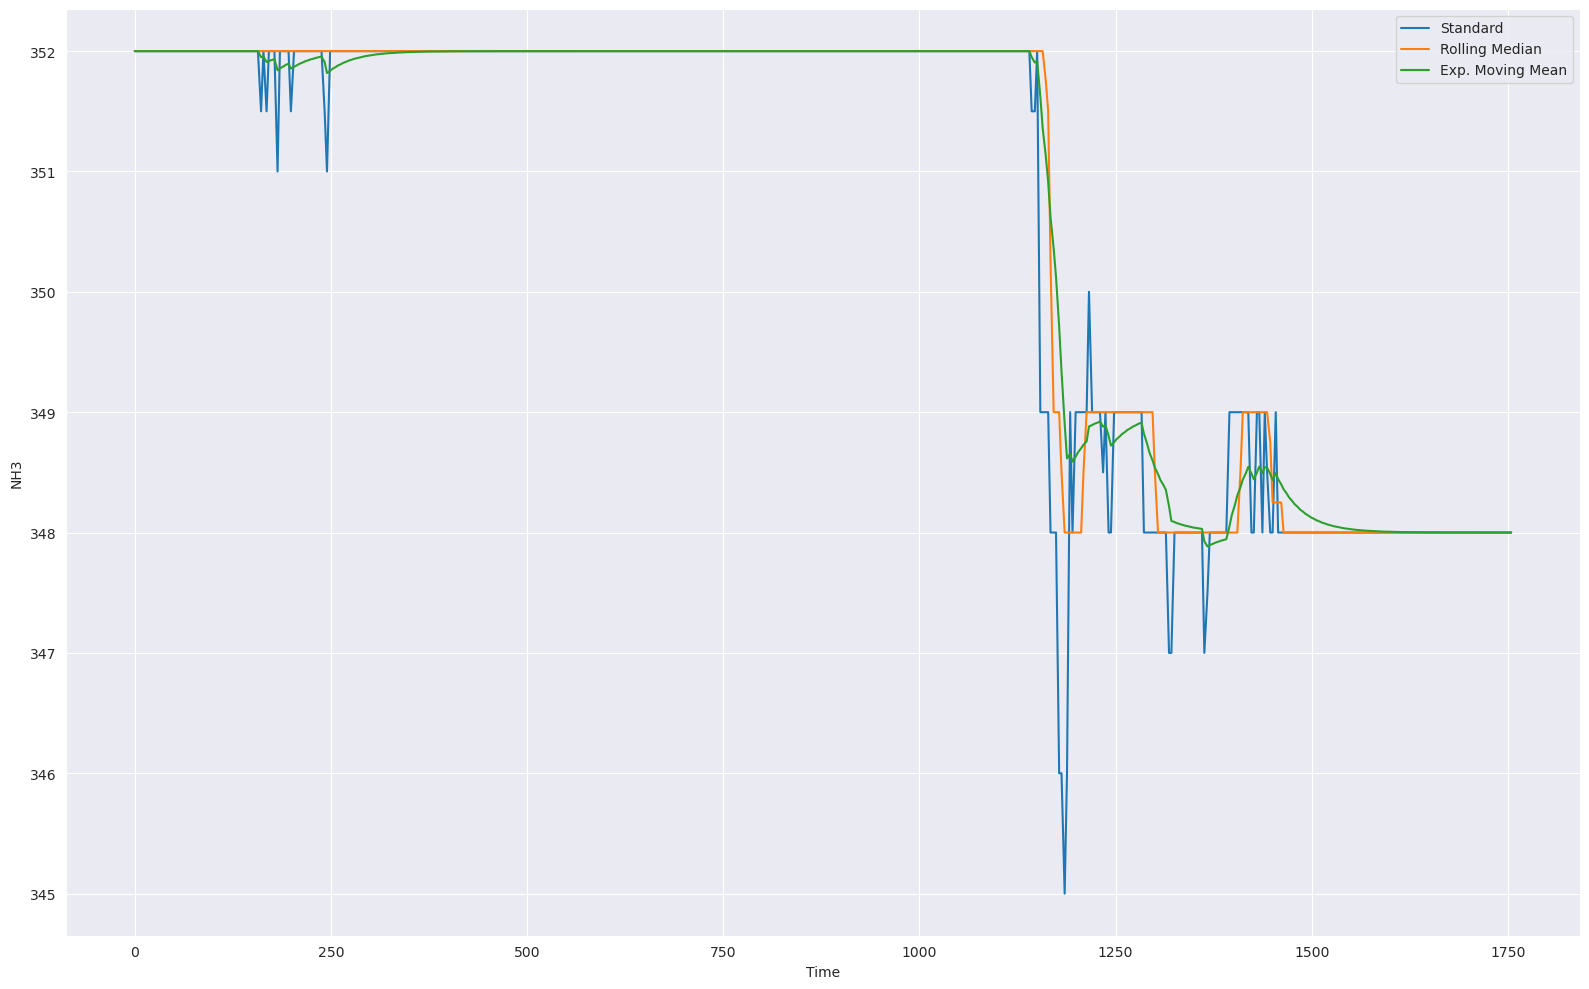

18436       0.0
18437       4.0
18438       7.0
18439      11.0
18440      14.0
          ...  
19317    3078.0
19318    3082.0
19319    3085.0
19320    3089.0
19321    3092.0
Name: Time, Length: 886, dtype: float64


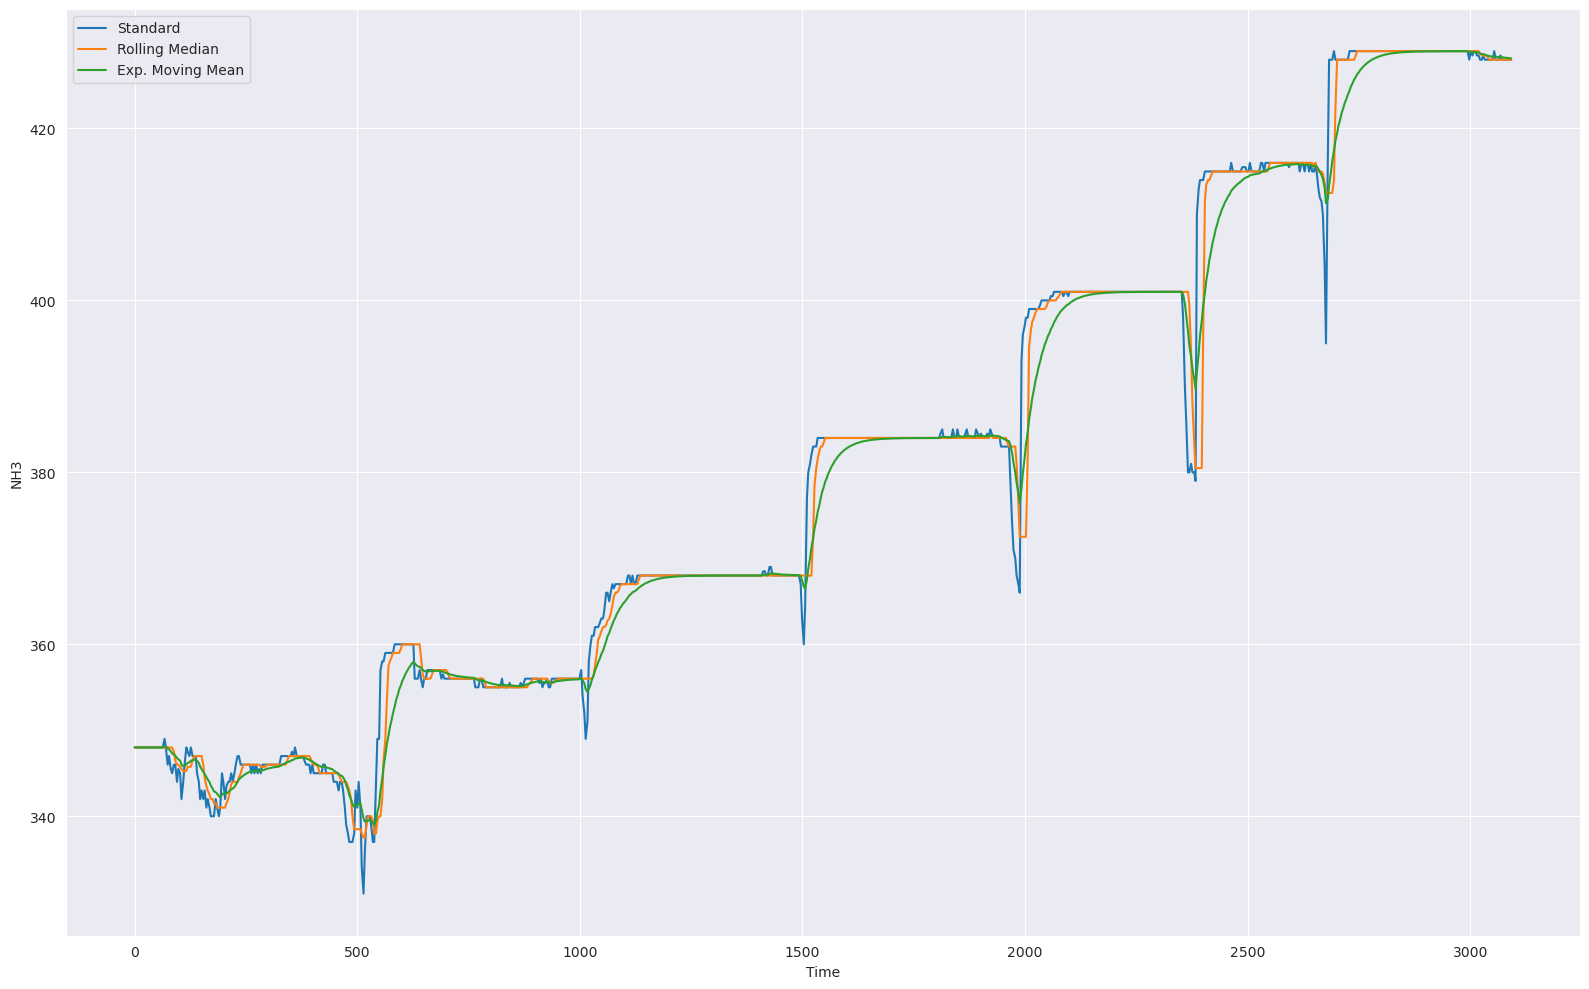

19324       0.0
19325       3.0
19326       7.0
19327      10.0
19328      14.0
          ...  
21003    5866.0
21004    5869.0
21005    5873.0
21006    5876.0
21007    5880.0
Name: Time, Length: 1684, dtype: float64


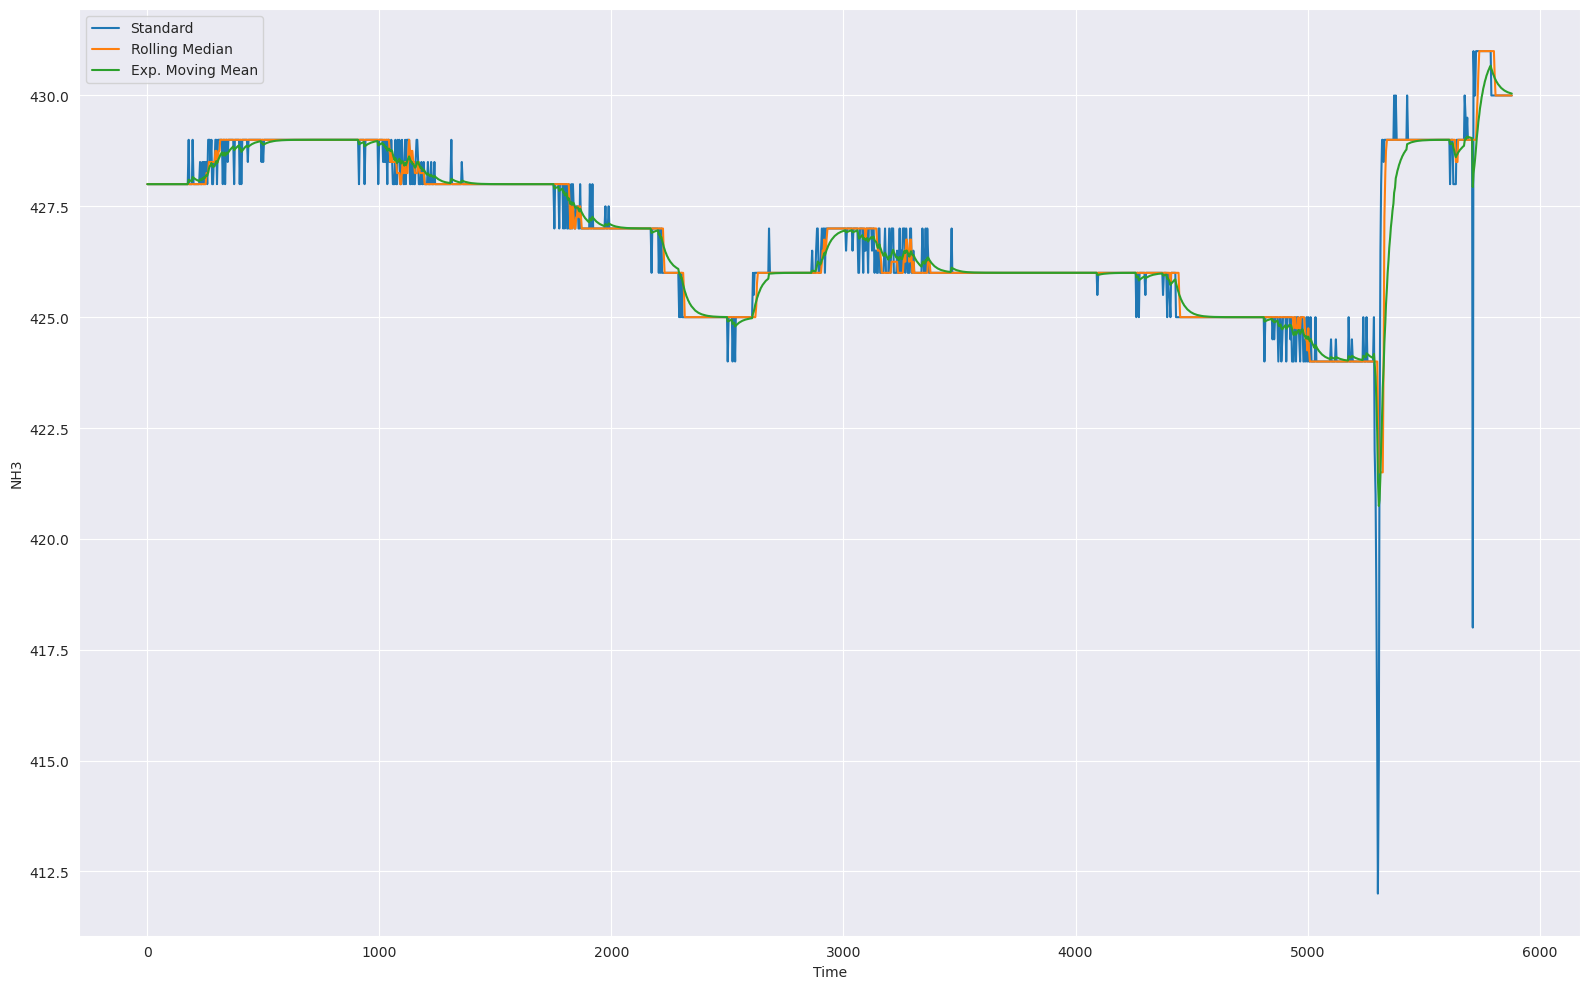

21010     0.0
21011     3.0
21012     7.0
21013    10.0
21014    14.0
21015    17.0
21016    21.0
21017    24.0
Name: Time, dtype: float64


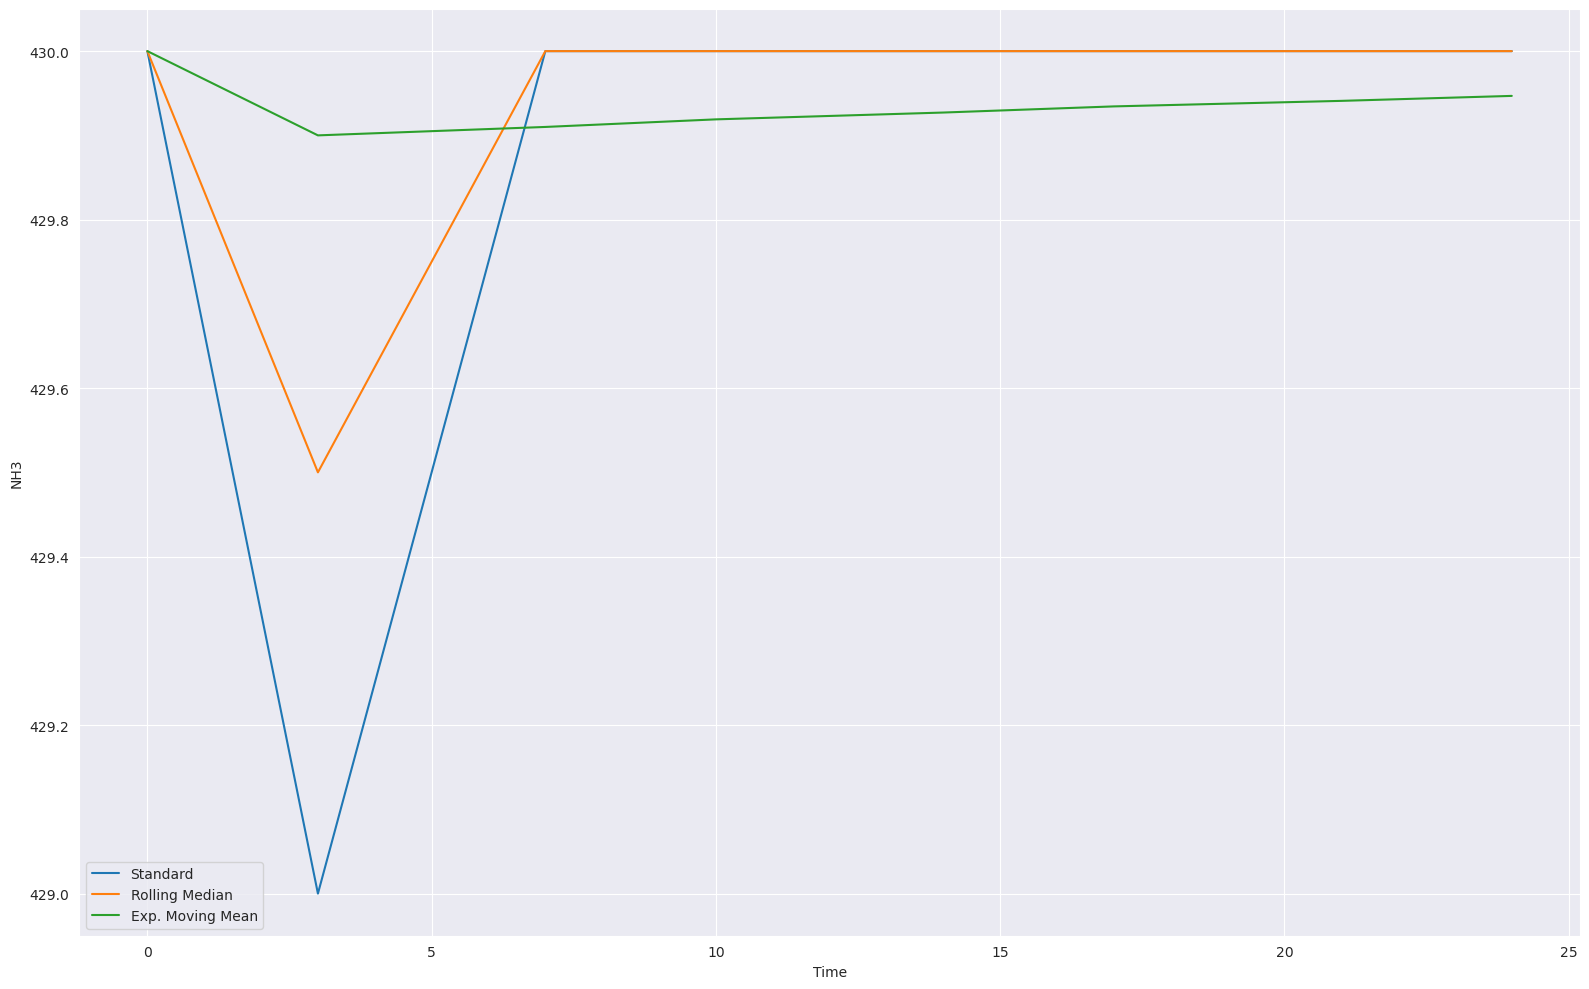

KeyError: np.int64(21020)

In [5]:
midx = np.where(df['Time'].isnull())[0]
midx
for i, n in enumerate(midx[:-1]):
    m = midx[i + 1]
    dfs = df[n + 1:m - 1]
    dfs.loc[:, 'Time'] = pd.to_datetime(dfs.loc[:, 'Time'], format='%Y-%m-%d %H:%M:%S')

    dt0 = dfs.loc[n + 1, 'Time']
    dt = dfs['Time'] - dt0
    dt = dt.dt.total_seconds()
    print(dt)
    yph = dfs['smoothed_pH']
    yph = dfs['analog_pH']
    ynh3 = dfs['smoothed_NH3']

    yphr = yph.rolling(10, min_periods=1).median()
    yphe = yph.ewm(alpha=0.1, adjust=False).mean()

    ynh3r = ynh3.rolling(10, min_periods=1).median()
    ynh3e = ynh3.ewm(alpha=0.1, adjust=False).mean()

    y_label = 'NH3'
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.plot(dt, ynh3, label='Standard')
    ax.plot(dt, ynh3r, label='Rolling Median')
    ax.plot(dt, ynh3e, label='Exp. Moving Mean')
    ax.set_xlabel('Time')
    ax.set_ylabel(y_label)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'PumpControl/img/{y_label}-segment-{i}.png')
    plt.show()